In [47]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
)

from scipy.special import expit

from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.calibration import calibration_curve

# 1 Required artifacts, configs, and no-leakage policy
### 1.1 paths

In [2]:
step1_dir = Path("./results_step1")
step2_dir = Path("./results_step2")
step3_dir = Path("./results_step3")
step4_dir = Path("./results_step4")
step4_dir.mkdir(parents=True, exist_ok=True)

### 1.2 Required artifacts

In [3]:
step1_required_files = [
    "validation_pairs.parquet",
    "test_pairs.parquet",
    "validation_split_model_universe.parquet",
    "test_split_model_universe.parquet",
    "step1_config.json",
]

step2_required_files = [
    "final_train_pairs_used_by_bpr.parquet",
    "final_train_pairs_used_by_bpr_info.json",
    "user_embeddings_p_u.npy",
    "item_embeddings_q_i.npy",
    "item_bias.npy",
    "user_index_mapping.parquet",
    "item_index_mapping.parquet",
    "final_step2_config.json",
    "final_pairwise_evaluation.parquet",
]

step3_optional_but_useful_files = [
    "final_item_dbscan_labels.parquet",
    "final_step3_config.json",
]

def make_file_check(base_dir, filenames, source_name, required=True):
    rows = []
    for filename in filenames:
        path = base_dir / filename
        rows.append({
            "source": source_name,
            "filename": filename,
            "required": required,
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / (1024 ** 2), 4) if path.exists() else np.nan,
        })
    return pd.DataFrame(rows)

artifact_check = pd.concat(
    [
        make_file_check(step1_dir, step1_required_files, "step1", required=True),
        make_file_check(step2_dir, step2_required_files, "step2", required=True),
        make_file_check(step3_dir, step3_optional_but_useful_files, "step3", required=False),
    ],
    ignore_index=True,
)

display(artifact_check)

missing_required = artifact_check[
    artifact_check["required"] & ~artifact_check["exists"]
]

if len(missing_required) > 0:
    display(missing_required)
    raise FileNotFoundError("Missing required artifacts for Step 4.")

print("Required artifact check passed.")

,source,filename,required,exists,size_mb
0,step1,validation_pairs.parquet,True,True,1.9347
1,step1,test_pairs.parquet,True,True,2.0204
2,step1,validation_split_model_universe.parquet,True,True,1.0917
3,step1,test_split_model_universe.parquet,True,True,1.1787
4,step1,step1_config.json,True,True,0.0006
5,step2,final_train_pairs_used_by_bpr.parquet,True,True,22.8153
6,step2,final_train_pairs_used_by_bpr_info.json,True,True,0.0006
7,step2,user_embeddings_p_u.npy,True,True,1.1530
8,step2,item_embeddings_q_i.npy,True,True,0.7936
9,step2,item_bias.npy,True,True,0.0125


Required artifact check passed.


### 1.3 Load configs

In [4]:
with open(step1_dir / "step1_config.json", "r") as f:
    step1_config = json.load(f)

with open(step2_dir / "final_step2_config.json", "r") as f:
    step2_config = json.load(f)

if (step3_dir / "final_step3_config.json").exists():
    with open(step3_dir / "final_step3_config.json", "r") as f:
        step3_config = json.load(f)
else:
    step3_config = {}

random_seed = int(
    step2_config.get(
        "random_seed",
        step1_config.get("random_seed", step1_config.get("seed", 42)),
    )
)

random.seed(random_seed)
np.random.seed(random_seed)

config_summary = pd.DataFrame([
    {
        "config": "step1",
        "random_seed": step1_config.get("random_seed", step1_config.get("seed")),
        "pair_min_diff": step1_config.get("pair_min_diff"),
        "min_user_ratings": step1_config.get("min_user_ratings"),
        "min_movie_ratings": step1_config.get("min_movie_ratings"),
        "split_strategy": step1_config.get("split_strategy"),
    },
    {
        "config": "step2",
        "random_seed": step2_config.get("random_seed"),
        "embedding_dim": step2_config.get("embedding_dim"),
        "learning_rate": step2_config.get("learning_rate"),
        "reg_lambda": step2_config.get("reg_lambda"),
        "selection_metric": step2_config.get("selection_metric"),
        "final_experiment_name": step2_config.get("final_experiment_name"),
        "test_used_for_selection": step2_config.get("test_used_for_selection"),
    },
    {
        "config": "step3",
        "random_seed": step3_config.get("random_seed"),
        "selected_entity": step3_config.get("selected_entity"),
        "selected_space": step3_config.get("selected_space"),
        "selected_metric": step3_config.get("selected_metric"),
        "n_clusters_excluding_noise": step3_config.get("n_clusters_excluding_noise"),
        "n_noise_items": step3_config.get("n_noise_items"),
    },
])

display(config_summary)
print("Random seed used in Step 4:", random_seed)

,config,random_seed,pair_min_diff,min_user_ratings,min_movie_ratings,split_strategy,embedding_dim,learning_rate,reg_lambda,selection_metric,final_experiment_name,test_used_for_selection,selected_entity,selected_space,selected_metric,n_clusters_excluding_noise,n_noise_items
0,step1,42.0,2.0,40.0,10.0,per_user_temporal_split_with_same_timestamp_gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,step2,NaN,NaN,NaN,NaN,NaN,64.0,0.0003,0.0001,validation_macro_accuracy_best,pair_sampling_gap2_random_cap_dim64_lr3em04_re...,False,NaN,NaN,NaN,NaN,NaN
2,step3,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,items,l2_normalized,cosine,2.0,1246.0


Random seed used in Step 4: 42


### 1.4 Load pairwise data

In [5]:
train_pairs = pd.read_parquet(step2_dir / "final_train_pairs_used_by_bpr.parquet")
val_pairs = pd.read_parquet(step1_dir / "validation_pairs.parquet")
test_pairs = pd.read_parquet(step1_dir / "test_pairs.parquet")

### 1.5 Standardize pairwise columns

In [6]:
def standardize_pair_columns(pair_df):
    df = pair_df.copy()
    
    rename_map = {
        "preferred_item": "pos_item",
        "less_preferred_item": "neg_item",
        "rating_preferred": "rating_pos",
        "rating_less_preferred": "rating_neg",
        "timestamp_preferred": "timestamp_pos",
        "timestamp_less_preferred": "timestamp_neg",
    }
    
    active_rename_map = {
        old_name: new_name
        for old_name, new_name in rename_map.items()
        if old_name in df.columns
    }
    
    df = df.rename(columns=active_rename_map)
    
    required_columns = [
        "user_id",
        "pos_item",
        "neg_item",
        "rating_pos",
        "rating_neg",
        "rating_diff",
    ]
    
    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]
    
    if missing_columns:
        raise ValueError(
            f"Missing required pairwise columns after standardization: {missing_columns}"
        )
    
    return df

train_pairs = standardize_pair_columns(train_pairs)
val_pairs = standardize_pair_columns(val_pairs)
test_pairs = standardize_pair_columns(test_pairs)

### 1.6 Load embeddings and mappings

In [7]:
user_embeddings = np.load(step2_dir / "user_embeddings_p_u.npy")
item_embeddings = np.load(step2_dir / "item_embeddings_q_i.npy")
item_bias = np.load(step2_dir / "item_bias.npy").reshape(-1)

user_index_mapping = (
    pd.read_parquet(step2_dir / "user_index_mapping.parquet")
    .sort_values("user_idx")
    .reset_index(drop=True)
)

item_index_mapping = (
    pd.read_parquet(step2_dir / "item_index_mapping.parquet")
    .sort_values("item_idx")
    .reset_index(drop=True)
)

user_to_idx = dict(zip(user_index_mapping["user_id"], user_index_mapping["user_idx"]))
item_to_idx = dict(zip(item_index_mapping["movie_id"], item_index_mapping["item_idx"]))

n_users = len(user_index_mapping)
n_items = len(item_index_mapping)
embedding_dim = user_embeddings.shape[1]

### 1.7 Guardrail checks

In [8]:
assert np.isfinite(user_embeddings).all()
assert np.isfinite(item_embeddings).all()
assert np.isfinite(item_bias).all()

assert user_embeddings.shape[0] == n_users
assert item_embeddings.shape[0] == n_items
assert item_bias.shape[0] == n_items
assert user_embeddings.shape[1] == item_embeddings.shape[1]

assert user_index_mapping["user_idx"].min() == 0
assert user_index_mapping["user_idx"].max() == n_users - 1
assert user_index_mapping["user_idx"].is_unique
assert user_index_mapping["user_id"].is_unique

assert item_index_mapping["item_idx"].min() == 0
assert item_index_mapping["item_idx"].max() == n_items - 1
assert item_index_mapping["item_idx"].is_unique
assert item_index_mapping["movie_id"].is_unique

def pairwise_sanity_summary(pair_df, split_name):
    users = set(pair_df["user_id"].unique())
    items = set(pair_df["pos_item"].unique()) | set(pair_df["neg_item"].unique())
    
    semantic_duplicates = pair_df.duplicated(
        ["user_id", "pos_item", "neg_item"]
    ).sum()
    
    reverse_conflicts = len(
        set(zip(pair_df["user_id"], pair_df["pos_item"], pair_df["neg_item"]))
        &
        set(zip(pair_df["user_id"], pair_df["neg_item"], pair_df["pos_item"]))
    )
    
    return {
        "split": split_name,
        "rows": len(pair_df),
        "users": len(users),
        "items": len(items),
        "min_rating_diff": int(pair_df["rating_diff"].min()),
        "all_rating_diff_ge_2": bool(pair_df["rating_diff"].ge(2).all()),
        "same_pos_neg": int((pair_df["pos_item"] == pair_df["neg_item"]).sum()),
        "semantic_duplicates": int(semantic_duplicates),
        "reverse_conflicts": int(reverse_conflicts),
        "users_missing_from_bpr_mapping": len(users - set(user_to_idx.keys())),
        "items_missing_from_bpr_mapping": len(items - set(item_to_idx.keys())),
    }

pair_sanity = pd.DataFrame([
    pairwise_sanity_summary(train_pairs, "train_final_bpr_pairs"),
    pairwise_sanity_summary(val_pairs, "validation_pairs"),
    pairwise_sanity_summary(test_pairs, "test_pairs"),
])

display(pair_sanity)

assert pair_sanity["all_rating_diff_ge_2"].all()
assert pair_sanity["same_pos_neg"].sum() == 0
assert pair_sanity["semantic_duplicates"].sum() == 0
assert pair_sanity["reverse_conflicts"].sum() == 0
assert pair_sanity["users_missing_from_bpr_mapping"].sum() == 0
assert pair_sanity["items_missing_from_bpr_mapping"].sum() == 0

print("Pairwise sanity and mapping checks passed.")

,split,rows,users,items,min_rating_diff,all_rating_diff_ge_2,same_pos_neg,semantic_duplicates,reverse_conflicts,users_missing_from_bpr_mapping,items_missing_from_bpr_mapping
0,train_final_bpr_pairs,5692244,4722,3250,2,True,0,0,0,0,0
1,validation_pairs,478098,4158,3193,2,True,0,0,0,0,0
2,test_pairs,507550,4164,3222,2,True,0,0,0,0,0


Pairwise sanity and mapping checks passed.


### 1.8 Decision log for Block 1

In [9]:
block1_decisions = pd.DataFrame([
    {
        "decision_area": "training_pairs",
        "selected_value": "results_step2/final_train_pairs_used_by_bpr.parquet",
        "evidence": (
            "Step 4 classical predictors should be compared to the final BPR model. "
            "Therefore, their training data should match the final BPR pair sample, "
            "not an earlier or alternative pair universe."
        ),
    },
    {
        "decision_area": "validation_and_test_pairs",
        "selected_value": "Step 1 validation_pairs.parquet and test_pairs.parquet",
        "evidence": (
            "Validation and test comparisons are held-out pairwise splits. "
            "Validation will be used for model selection; test will be used only for final reporting."
        ),
    },
    {
        "decision_area": "label_leakage_policy",
        "selected_value": "Do not use rating_pos, rating_neg, or rating_diff as model features",
        "evidence": (
            "These columns define or reveal the preference strength. "
            "Using them would inflate performance and would not reflect an embedding-derived predictor."
        ),
    },
    {
        "decision_area": "feature_source",
        "selected_value": "BPR user embeddings, item embeddings, item bias, optional Step 3 item DBSCAN labels later",
        "evidence": (
            "The project requires Step 4 predictors to use features derived from MF embeddings. "
            "Step 3 DBSCAN labels may be useful for subgroup analysis and Step 5 preparation."
        ),
    },
])

display(block1_decisions)

block1_decisions.to_parquet(step4_dir / "block1_decisions.parquet", index=False)
pair_sanity.to_parquet(step4_dir / "block1_pair_sanity.parquet", index=False)

print("Saved:")
print(step4_dir / "block1_decisions.parquet")
print(step4_dir / "block1_pair_sanity.parquet")

,decision_area,selected_value,evidence
0,training_pairs,results_step2/final_train_pairs_used_by_bpr.pa...,Step 4 classical predictors should be compared...
1,validation_and_test_pairs,Step 1 validation_pairs.parquet and test_pairs...,Validation and test comparisons are held-out p...
2,label_leakage_policy,"Do not use rating_pos, rating_neg, or rating_d...",These columns define or reveal the preference ...
3,feature_source,"BPR user embeddings, item embeddings, item bia...",The project requires Step 4 predictors to use ...


Saved:
results_step4\block1_decisions.parquet
results_step4\block1_pair_sanity.parquet


# 2 Balanced Pairwise Classification View and MF Baseline
### 2.1 Add BPR indices to all pairwise splits

In [10]:
def add_pair_indices_if_needed(pair_df, split_name, user_to_idx, item_to_idx):
    df = pair_df.copy()
    
    if "user_idx" not in df.columns:
        df["user_idx"] = df["user_id"].map(user_to_idx)
    if "pos_item_idx" not in df.columns:
        df["pos_item_idx"] = df["pos_item"].map(item_to_idx)
    if "neg_item_idx" not in df.columns:
        df["neg_item_idx"] = df["neg_item"].map(item_to_idx)
    
    missing_summary = {
        "split": split_name,
        "rows": len(df),
        "missing_user_idx": int(df["user_idx"].isna().sum()),
        "missing_pos_item_idx": int(df["pos_item_idx"].isna().sum()),
        "missing_neg_item_idx": int(df["neg_item_idx"].isna().sum()),
    }
    
    if (
        missing_summary["missing_user_idx"] > 0
        or missing_summary["missing_pos_item_idx"] > 0
        or missing_summary["missing_neg_item_idx"] > 0
    ):
        raise ValueError(f"{split_name}: missing index mappings: {missing_summary}")
    
    df["user_idx"] = df["user_idx"].astype("int64")
    df["pos_item_idx"] = df["pos_item_idx"].astype("int64")
    df["neg_item_idx"] = df["neg_item_idx"].astype("int64")
    
    return df, missing_summary


train_pairs_idx, train_idx_summary = add_pair_indices_if_needed(
    train_pairs,
    "train",
    user_to_idx,
    item_to_idx,
)

val_pairs_idx, val_idx_summary = add_pair_indices_if_needed(
    val_pairs,
    "validation",
    user_to_idx,
    item_to_idx,
)

test_pairs_idx, test_idx_summary = add_pair_indices_if_needed(
    test_pairs,
    "test",
    user_to_idx,
    item_to_idx,
)

index_mapping_summary = pd.DataFrame([
    train_idx_summary,
    val_idx_summary,
    test_idx_summary,
])

display(index_mapping_summary)

assert index_mapping_summary[
    ["missing_user_idx", "missing_pos_item_idx", "missing_neg_item_idx"]
].sum().sum() == 0

print("Index mapping checks passed.")

,split,rows,missing_user_idx,missing_pos_item_idx,missing_neg_item_idx
0,train,5692244,0,0,0
1,validation,478098,0,0,0
2,test,507550,0,0,0


Index mapping checks passed.


### 2.2 Compute MF/BPR baseline scores

In [11]:
def compute_mf_pair_score(pair_df_idx, user_embeddings, item_embeddings, item_bias):
    user_idx = pair_df_idx["user_idx"].to_numpy(dtype=np.int64)
    pos_idx = pair_df_idx["pos_item_idx"].to_numpy(dtype=np.int64)
    neg_idx = pair_df_idx["neg_item_idx"].to_numpy(dtype=np.int64)
    
    user_vecs = user_embeddings[user_idx]
    pos_vecs = item_embeddings[pos_idx]
    neg_vecs = item_embeddings[neg_idx]
    
    dot_diff = np.sum(user_vecs * (pos_vecs - neg_vecs), axis=1)
    bias_diff = item_bias[pos_idx] - item_bias[neg_idx]
    
    return dot_diff + bias_diff


train_mf_score = compute_mf_pair_score(
    train_pairs_idx,
    user_embeddings,
    item_embeddings,
    item_bias,
)

val_mf_score = compute_mf_pair_score(
    val_pairs_idx,
    user_embeddings,
    item_embeddings,
    item_bias,
)

test_mf_score = compute_mf_pair_score(
    test_pairs_idx,
    user_embeddings,
    item_embeddings,
    item_bias,
)

mf_score_summary = pd.DataFrame([
    {
        "split": "train",
        "pairs": len(train_mf_score),
        "mean_score": float(np.mean(train_mf_score)),
        "std_score": float(np.std(train_mf_score)),
        "min_score": float(np.min(train_mf_score)),
        "median_score": float(np.median(train_mf_score)),
        "max_score": float(np.max(train_mf_score)),
        "share_score_positive": float(np.mean(train_mf_score > 0)),
    },
    {
        "split": "validation",
        "pairs": len(val_mf_score),
        "mean_score": float(np.mean(val_mf_score)),
        "std_score": float(np.std(val_mf_score)),
        "min_score": float(np.min(val_mf_score)),
        "median_score": float(np.median(val_mf_score)),
        "max_score": float(np.max(val_mf_score)),
        "share_score_positive": float(np.mean(val_mf_score > 0)),
    },
    {
        "split": "test",
        "pairs": len(test_mf_score),
        "mean_score": float(np.mean(test_mf_score)),
        "std_score": float(np.std(test_mf_score)),
        "min_score": float(np.min(test_mf_score)),
        "median_score": float(np.median(test_mf_score)),
        "max_score": float(np.max(test_mf_score)),
        "share_score_positive": float(np.mean(test_mf_score > 0)),
    },
])

display(mf_score_summary.round(6))

,split,pairs,mean_score,std_score,min_score,median_score,max_score,share_score_positive
0,train,5692244,2.902715,2.113266,-8.205485,2.688258,17.793907,0.939796
1,validation,478098,1.913548,2.329078,-7.971659,1.567559,17.996964,0.809004
2,test,507550,2.040658,2.391282,-10.978682,1.731171,17.576082,0.818034


### 2.3 Evaluate MF baseline as balanced directional classifier

In [12]:
def evaluate_directional_scores_from_original_pairs(score_diff, split_name):
    """
    Original pairs are positive-direction examples:
    pos_item is preferred over neg_item.

    We create a balanced directional classification view:
    - original direction: y = 1, score = score_diff
    - reversed direction: y = 0, score = -score_diff
    """
    y_true = np.concatenate([
        np.ones(len(score_diff), dtype=np.int8),
        np.zeros(len(score_diff), dtype=np.int8),
    ])
    
    directional_score = np.concatenate([
        score_diff,
        -score_diff,
    ])
    
    y_prob = expit(directional_score)
    y_pred = (y_prob >= 0.5).astype(np.int8)
    
    return {
        "split": split_name,
        "directional_examples": len(y_true),
        "original_pairs": len(score_diff),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob, labels=[0, 1]),
        "brier_score": brier_score_loss(y_true, y_prob),
        "original_pair_accuracy": float(np.mean(score_diff > 0)),
        "mean_prob_original_direction": float(np.mean(expit(score_diff))),
        "mean_prob_reversed_direction": float(np.mean(expit(-score_diff))),
    }


mf_baseline_eval = pd.DataFrame([
    evaluate_directional_scores_from_original_pairs(train_mf_score, "train"),
    evaluate_directional_scores_from_original_pairs(val_mf_score, "validation"),
    evaluate_directional_scores_from_original_pairs(test_mf_score, "test"),
])

display(mf_baseline_eval.round(6))

,split,directional_examples,original_pairs,accuracy,balanced_accuracy,auc,log_loss,brier_score,original_pair_accuracy,mean_prob_original_direction,mean_prob_reversed_direction
0,train,11384488,5692244,0.939796,0.939796,0.985389,0.184090,0.050559,0.939796,0.862351,0.137649
1,validation,956196,478098,0.809004,0.809004,0.896833,0.402563,0.130652,0.809004,0.742392,0.257608
2,test,1015100,507550,0.818034,0.818034,0.903393,0.393546,0.125943,0.818034,0.753923,0.246077


### 2.4 Macro-by-user MF baseline

In [13]:
def user_macro_pairwise_accuracy(pair_df_idx, score_diff, split_name):
    temp = pair_df_idx[["user_id"]].copy()
    temp["correct"] = score_diff > 0
    
    user_acc = (
        temp
        .groupby("user_id")["correct"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"count": "pairs", "mean": "user_accuracy"})
    )
    
    summary = {
        "split": split_name,
        "users": int(len(user_acc)),
        "pairs": int(len(temp)),
        "macro_user_accuracy": float(user_acc["user_accuracy"].mean()),
        "median_user_accuracy": float(user_acc["user_accuracy"].median()),
        "p10_user_accuracy": float(user_acc["user_accuracy"].quantile(0.10)),
        "p25_user_accuracy": float(user_acc["user_accuracy"].quantile(0.25)),
        "p75_user_accuracy": float(user_acc["user_accuracy"].quantile(0.75)),
        "p90_user_accuracy": float(user_acc["user_accuracy"].quantile(0.90)),
        "min_user_accuracy": float(user_acc["user_accuracy"].min()),
        "max_user_accuracy": float(user_acc["user_accuracy"].max()),
    }
    
    return summary, user_acc


train_user_mf_summary, train_user_mf_acc = user_macro_pairwise_accuracy(
    train_pairs_idx,
    train_mf_score,
    "train",
)

val_user_mf_summary, val_user_mf_acc = user_macro_pairwise_accuracy(
    val_pairs_idx,
    val_mf_score,
    "validation",
)

test_user_mf_summary, test_user_mf_acc = user_macro_pairwise_accuracy(
    test_pairs_idx,
    test_mf_score,
    "test",
)

mf_user_macro_eval = pd.DataFrame([
    train_user_mf_summary,
    val_user_mf_summary,
    test_user_mf_summary,
])

display(mf_user_macro_eval.round(6))

train_user_mf_acc.to_parquet(step4_dir / "mf_train_user_accuracy.parquet", index=False)
val_user_mf_acc.to_parquet(step4_dir / "mf_validation_user_accuracy.parquet", index=False)
test_user_mf_acc.to_parquet(step4_dir / "mf_test_user_accuracy.parquet", index=False)

,split,users,pairs,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,min_user_accuracy,max_user_accuracy
0,train,4722,5692244,0.948651,0.955678,0.900023,0.930000,0.974684,0.989247,0.7505,1.0
1,validation,4158,478098,0.760839,0.801585,0.500000,0.660836,0.928571,1.000000,0.0000,1.0
2,test,4164,507550,0.774218,0.823529,0.500000,0.666667,0.938838,1.000000,0.0000,1.0


### 2.5 Save Block 2 outputs and decision log

In [14]:
mf_score_summary.to_parquet(
    step4_dir / "block2_mf_score_summary.parquet",
    index=False,
)

mf_baseline_eval.to_parquet(
    step4_dir / "block2_mf_baseline_eval.parquet",
    index=False,
)

mf_user_macro_eval.to_parquet(
    step4_dir / "block2_mf_user_macro_eval.parquet",
    index=False,
)

block2_decisions = pd.DataFrame([
    {
        "decision_area": "classification_view",
        "selected_value": "balanced directional pairwise classification",
        "evidence": (
            "Each original pair pos_item > neg_item becomes a positive example. "
            "The reversed direction becomes a negative example. "
            "This creates a balanced task and enables AUC, log loss, Brier score, and calibration analysis."
        ),
    },
    {
        "decision_area": "mf_baseline_score",
        "selected_value": "p_u dot q_pos - p_u dot q_neg + item_bias_pos - item_bias_neg",
        "evidence": (
            "The project requires comparison against the MF pairwise score. "
            "The final Step 2 BPR model includes item bias, so the fair baseline uses the complete final model score."
        ),
    },
    {
        "decision_area": "probability_transform",
        "selected_value": "sigmoid(MF score difference)",
        "evidence": (
            "BPR optimizes log-sigmoid of the score difference, so sigmoid(score_diff) is the natural probability-like output. "
            "It is not assumed to be perfectly calibrated; calibration will be evaluated using log loss and Brier score."
        ),
    },
    {
        "decision_area": "macro_user_evaluation",
        "selected_value": "report macro-by-user accuracy in addition to micro metrics",
        "evidence": (
            "Micro metrics can be dominated by users with many pairwise comparisons. "
            "Macro-by-user accuracy gives each evaluated user equal weight and prepares later fairness analysis."
        ),
    },
])

display(block2_decisions)

block2_decisions.to_parquet(
    step4_dir / "block2_decisions.parquet",
    index=False,
)

print("Saved Block 2 outputs:")
print(step4_dir / "block2_mf_score_summary.parquet")
print(step4_dir / "block2_mf_baseline_eval.parquet")
print(step4_dir / "block2_mf_user_macro_eval.parquet")
print(step4_dir / "block2_decisions.parquet")

,decision_area,selected_value,evidence
0,classification_view,balanced directional pairwise classification,Each original pair pos_item > neg_item becomes...
1,mf_baseline_score,p_u dot q_pos - p_u dot q_neg + item_bias_pos ...,The project requires comparison against the MF...
2,probability_transform,sigmoid(MF score difference),BPR optimizes log-sigmoid of the score differe...
3,macro_user_evaluation,report macro-by-user accuracy in addition to m...,Micro metrics can be dominated by users with m...


Saved Block 2 outputs:
results_step4\block2_mf_score_summary.parquet
results_step4\block2_mf_baseline_eval.parquet
results_step4\block2_mf_user_macro_eval.parquet
results_step4\block2_decisions.parquet


# 3 Classification Setup and Feature Plan

Classical classifiers require a binary label.

For a directional example `(user, first_item, second_item)`:

- `label = 1` means the first item is preferred over the second item.
- `label = 0` means the second item is preferred over the first item.

Training policy:
Use random-swap on the full final BPR train pairs. Each original train pair appears once, either in the original direction or the reversed direction. This preserves the same original train pair universe as the final BPR model and avoids doubling the training set.

Validation/test policy:
Use symmetric evaluation. Each held-out pair appears in both directions. This gives exactly balanced labels and supports accuracy, AUC, log loss, Brier score, and calibration evaluation.

### 3.1 Classification policy summary

In [15]:
classification_policy_summary = pd.DataFrame([
    {
        "split": "train",
        "direction_policy": "random_swap",
        "original_pairs": len(train_pairs_idx),
        "directional_examples": len(train_pairs_idx),
        "expected_positive_share": 0.5,
        "reason": "Use each final BPR train pair once while creating both label classes in expectation.",
    },
    {
        "split": "validation",
        "direction_policy": "symmetric",
        "original_pairs": len(val_pairs_idx),
        "directional_examples": 2 * len(val_pairs_idx),
        "expected_positive_share": 0.5,
        "reason": "Balanced held-out evaluation.",
    },
    {
        "split": "test",
        "direction_policy": "symmetric",
        "original_pairs": len(test_pairs_idx),
        "directional_examples": 2 * len(test_pairs_idx),
        "expected_positive_share": 0.5,
        "reason": "Balanced final held-out evaluation.",
    },
])

display(classification_policy_summary)

classification_policy_summary.to_parquet(
    step4_dir / "block3_classification_policy_summary.parquet",
    index=False,
)

,split,direction_policy,original_pairs,directional_examples,expected_positive_share,reason
0,train,random_swap,5692244,5692244,0.5,Use each final BPR train pair once while creat...
1,validation,symmetric,478098,956196,0.5,Balanced held-out evaluation.
2,test,symmetric,507550,1015100,0.5,Balanced final held-out evaluation.


### 3.2 Feature group plan

The Step 4 models use features derived from the final BPR embeddings.

We do not use `rating_pos`, `rating_neg`, or `rating_diff` as features because they directly reveal the preference strength and would cause leakage.

We test three feature groups:

1. `item_diff`: `q_first - q_second` plus item bias difference.
   This tests whether item vectors alone are enough.

2. `interaction`: `p_u * (q_first - q_second)` plus item bias difference.
   This tests user-specific preference alignment.

3. `user_item_diff`: `p_u` concatenated with `q_first - q_second` plus item bias difference.
   This tests whether adding the user vector improves prediction.

This is feature selection at the feature-group level, which is more meaningful for latent embeddings than selecting individual embedding dimensions.

In [16]:
feature_group_plan = pd.DataFrame([
    {
        "feature_group": "item_diff",
        "feature_dim": embedding_dim + 1,
        "uses_user_vector": False,
        "uses_item_difference": True,
        "uses_user_item_interaction": False,
        "description": "q_first - q_second plus item bias difference",
    },
    {
        "feature_group": "interaction",
        "feature_dim": embedding_dim + 1,
        "uses_user_vector": True,
        "uses_item_difference": True,
        "uses_user_item_interaction": True,
        "description": "p_u * (q_first - q_second) plus item bias difference",
    },
    {
        "feature_group": "user_item_diff",
        "feature_dim": 2 * embedding_dim + 1,
        "uses_user_vector": True,
        "uses_item_difference": True,
        "uses_user_item_interaction": False,
        "description": "p_u concatenated with q_first - q_second plus item bias difference",
    },
])

display(feature_group_plan)

feature_group_plan.to_parquet(
    step4_dir / "block3_feature_group_plan.parquet",
    index=False,
)

,feature_group,feature_dim,uses_user_vector,uses_item_difference,uses_user_item_interaction,description
0,item_diff,65,False,True,False,q_first - q_second plus item bias difference
1,interaction,65,True,True,True,p_u * (q_first - q_second) plus item bias diff...
2,user_item_diff,129,True,True,False,p_u concatenated with q_first - q_second plus ...


### 3.3 Block 3 decisions

In [17]:
block3_decisions = pd.DataFrame([
    {
        "decision_area": "directional_label_definition",
        "selected_value": "label=1 if first_item is preferred over second_item; label=0 otherwise",
        "evidence": (
            "Classical classifiers require binary labels. Original BPR pairs only encode pos_item > neg_item, "
            "so they must be converted into first_item/second_item classification examples."
        ),
    },
    {
        "decision_area": "train_direction_policy",
        "selected_value": "random_swap",
        "evidence": (
            "Random-swap keeps every original final BPR train pair exactly once, avoids doubling train size, "
            "and creates both classes in expectation."
        ),
    },
    {
        "decision_area": "validation_test_direction_policy",
        "selected_value": "symmetric",
        "evidence": (
            "Symmetric held-out evaluation creates exactly balanced labels for accuracy, AUC, log loss, Brier score, and calibration."
        ),
    },
    {
        "decision_area": "feature_representation_strategy",
        "selected_value": "compare pre-defined embedding-derived feature groups",
        "evidence": (
            "The Step 4 question asks whether user vectors, item vectors, or q_i - q_j matter most. "
            "The three feature groups directly test these alternatives."
        ),
    },
])

display(block3_decisions)

block3_decisions.to_parquet(
    step4_dir / "block3_decisions.parquet",
    index=False,
)

,decision_area,selected_value,evidence
0,directional_label_definition,label=1 if first_item is preferred over second...,Classical classifiers require binary labels. O...
1,train_direction_policy,random_swap,Random-swap keeps every original final BPR tra...
2,validation_test_direction_policy,symmetric,Symmetric held-out evaluation creates exactly ...
3,feature_representation_strategy,compare pre-defined embedding-derived feature ...,"The Step 4 question asks whether user vectors,..."


# 4 Directional Feature Builders and Sanity Checks

This block creates reusable functions for converting original pairwise BPR-style rows into classical ML features.

No model is trained in this block.

The goal is to verify that:
- random-swap train labels are created correctly;
- symmetric validation/test labels are created correctly;
- embedding-derived feature matrices have the expected dimensions;
- no leakage columns are used;
- MF directional scoring is consistent with the label convention.

### 4.1 Directional arrays and feature builder functions

In [18]:
def make_directional_arrays(
    pair_df_idx,
    mode,
    random_seed=42,
    sample_n=None,
):
    """
    Convert BPR-style pairs into directional classification arrays.

    Input pair convention:
        pos_item_idx is preferred over neg_item_idx.

    Output convention:
        label = 1 if first_item_idx is preferred over second_item_idx.
        label = 0 otherwise.

    mode="random_swap":
        one directional row per original pair.

    mode="symmetric":
        two directional rows per original pair.
    """
    if sample_n is not None:
        n_sample = min(sample_n, len(pair_df_idx))
        df = (
            pair_df_idx
            .sample(n=n_sample, random_state=random_seed)
            .reset_index(drop=True)
        )
    else:
        df = pair_df_idx.reset_index(drop=True)

    user_id = df["user_id"].to_numpy()
    user_idx = df["user_idx"].to_numpy(dtype=np.int32)
    pos_idx = df["pos_item_idx"].to_numpy(dtype=np.int32)
    neg_idx = df["neg_item_idx"].to_numpy(dtype=np.int32)

    n = len(df)

    if mode == "random_swap":
        rng = np.random.default_rng(random_seed)
        is_reversed = rng.random(n) < 0.5

        first_idx = np.where(is_reversed, neg_idx, pos_idx).astype(np.int32)
        second_idx = np.where(is_reversed, pos_idx, neg_idx).astype(np.int32)
        label = np.where(is_reversed, 0, 1).astype(np.int8)

        user_id_out = user_id
        user_idx_out = user_idx

    elif mode == "symmetric":
        user_id_out = np.concatenate([user_id, user_id])
        user_idx_out = np.concatenate([user_idx, user_idx]).astype(np.int32)

        first_idx = np.concatenate([pos_idx, neg_idx]).astype(np.int32)
        second_idx = np.concatenate([neg_idx, pos_idx]).astype(np.int32)

        label = np.concatenate([
            np.ones(n, dtype=np.int8),
            np.zeros(n, dtype=np.int8),
        ])

    else:
        raise ValueError("mode must be 'random_swap' or 'symmetric'")

    return {
        "user_id": user_id_out,
        "user_idx": user_idx_out,
        "first_item_idx": first_idx,
        "second_item_idx": second_idx,
        "label": label,
        "original_pair_count": n,
        "directional_row_count": len(label),
        "mode": mode,
    }


def build_embedding_features(
    directional_arrays,
    feature_group,
    user_embeddings,
    item_embeddings,
    item_bias,
):
    """
    Build embedding-derived features for one feature group.

    feature_group:
        item_diff:
            q_first - q_second, bias_first - bias_second

        interaction:
            p_u * (q_first - q_second), bias_first - bias_second

        user_item_diff:
            p_u, q_first - q_second, bias_first - bias_second
    """
    user_idx = directional_arrays["user_idx"]
    first_idx = directional_arrays["first_item_idx"]
    second_idx = directional_arrays["second_item_idx"]

    q_diff = item_embeddings[first_idx] - item_embeddings[second_idx]
    bias_diff = (
        item_bias[first_idx] - item_bias[second_idx]
    ).reshape(-1, 1)

    if feature_group == "item_diff":
        X = np.hstack([
            q_diff,
            bias_diff,
        ])

    elif feature_group == "interaction":
        p_u = user_embeddings[user_idx]
        X = np.hstack([
            p_u * q_diff,
            bias_diff,
        ])

    elif feature_group == "user_item_diff":
        p_u = user_embeddings[user_idx]
        X = np.hstack([
            p_u,
            q_diff,
            bias_diff,
        ])

    else:
        raise ValueError(
            "feature_group must be 'item_diff', 'interaction', or 'user_item_diff'"
        )

    y = directional_arrays["label"]

    return X.astype(np.float32, copy=False), y


def compute_mf_score_from_directional_arrays(
    directional_arrays,
    user_embeddings,
    item_embeddings,
    item_bias,
):
    """
    MF/BPR score for directional examples:
        p_u dot q_first - p_u dot q_second + b_first - b_second
    """
    user_idx = directional_arrays["user_idx"]
    first_idx = directional_arrays["first_item_idx"]
    second_idx = directional_arrays["second_item_idx"]

    p_u = user_embeddings[user_idx]
    q_diff = item_embeddings[first_idx] - item_embeddings[second_idx]
    bias_diff = item_bias[first_idx] - item_bias[second_idx]

    return np.einsum("ij,ij->i", p_u, q_diff) + bias_diff

### 4.2 Label sanity check on preview samples

In [19]:
preview_original_pairs = 50_000

train_preview_arrays = make_directional_arrays(
    train_pairs_idx,
    mode="random_swap",
    random_seed=random_seed,
    sample_n=preview_original_pairs,
)

val_preview_arrays = make_directional_arrays(
    val_pairs_idx,
    mode="symmetric",
    random_seed=random_seed,
    sample_n=preview_original_pairs,
)

test_preview_arrays = make_directional_arrays(
    test_pairs_idx,
    mode="symmetric",
    random_seed=random_seed,
    sample_n=preview_original_pairs,
)


def summarize_directional_arrays(arrays, split_name):
    return {
        "split": split_name,
        "mode": arrays["mode"],
        "original_pair_count": arrays["original_pair_count"],
        "directional_row_count": arrays["directional_row_count"],
        "positive_labels": int((arrays["label"] == 1).sum()),
        "negative_labels": int((arrays["label"] == 0).sum()),
        "positive_share": float((arrays["label"] == 1).mean()),
        "same_first_second_item": int(
            (
                arrays["first_item_idx"]
                == arrays["second_item_idx"]
            ).sum()
        ),
    }


directional_preview_summary = pd.DataFrame([
    summarize_directional_arrays(train_preview_arrays, "train_preview"),
    summarize_directional_arrays(val_preview_arrays, "validation_preview"),
    summarize_directional_arrays(test_preview_arrays, "test_preview"),
])

display(directional_preview_summary)

assert directional_preview_summary["same_first_second_item"].sum() == 0

directional_preview_summary.to_parquet(
    step4_dir / "block4_2_directional_preview_summary.parquet",
    index=False,
)

,split,mode,original_pair_count,directional_row_count,positive_labels,negative_labels,positive_share,same_first_second_item
0,train_preview,random_swap,50000,50000,25186,24814,0.50372,0
1,validation_preview,symmetric,50000,100000,50000,50000,0.50000,0
2,test_preview,symmetric,50000,100000,50000,50000,0.50000,0


### 4.3 Feature matrix sanity check

In [20]:
feature_sanity_rows = []

preview_arrays_by_split = {
    "train_preview": train_preview_arrays,
    "validation_preview": val_preview_arrays,
    "test_preview": test_preview_arrays,
}

for split_name, arrays in preview_arrays_by_split.items():
    for feature_group in feature_group_plan["feature_group"].tolist():
        X_preview, y_preview = build_embedding_features(
            arrays,
            feature_group,
            user_embeddings,
            item_embeddings,
            item_bias,
        )

        expected_dim = int(
            feature_group_plan
            .loc[
                feature_group_plan["feature_group"] == feature_group,
                "feature_dim",
            ]
            .iloc[0]
        )

        feature_sanity_rows.append({
            "split": split_name,
            "feature_group": feature_group,
            "rows": X_preview.shape[0],
            "feature_dim": X_preview.shape[1],
            "expected_feature_dim": expected_dim,
            "dtype": str(X_preview.dtype),
            "all_finite": bool(np.isfinite(X_preview).all()),
            "label_positive_share": float(y_preview.mean()),
            "estimated_memory_mb": X_preview.nbytes / (1024 ** 2),
        })

        del X_preview
        del y_preview

feature_sanity_summary = pd.DataFrame(feature_sanity_rows)

display(feature_sanity_summary.round(6))

assert (
    feature_sanity_summary["feature_dim"]
    == feature_sanity_summary["expected_feature_dim"]
).all()

assert feature_sanity_summary["all_finite"].all()

feature_sanity_summary.to_parquet(
    step4_dir / "block4_3_feature_sanity_summary.parquet",
    index=False,
)

,split,feature_group,rows,feature_dim,expected_feature_dim,dtype,all_finite,label_positive_share,estimated_memory_mb
0,train_preview,item_diff,50000,65,65,float32,True,0.50372,12.397766
1,train_preview,interaction,50000,65,65,float32,True,0.50372,12.397766
2,train_preview,user_item_diff,50000,129,129,float32,True,0.50372,24.604797
3,validation_preview,item_diff,100000,65,65,float32,True,0.50000,24.795532
4,validation_preview,interaction,100000,65,65,float32,True,0.50000,24.795532
5,validation_preview,user_item_diff,100000,129,129,float32,True,0.50000,49.209595
6,test_preview,item_diff,100000,65,65,float32,True,0.50000,24.795532
7,test_preview,interaction,100000,65,65,float32,True,0.50000,24.795532
8,test_preview,user_item_diff,100000,129,129,float32,True,0.50000,49.209595


### 4.4 MF directional consistency check

In [21]:
mf_directional_rows = []

for split_name, arrays in preview_arrays_by_split.items():
    mf_directional_score = compute_mf_score_from_directional_arrays(
        arrays,
        user_embeddings,
        item_embeddings,
        item_bias,
    )

    y_true = arrays["label"]
    y_prob = expit(mf_directional_score)
    y_pred = (y_prob >= 0.5).astype(np.int8)

    mf_directional_rows.append({
        "split": split_name,
        "rows": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob, labels=[0, 1]),
        "brier_score": brier_score_loss(y_true, y_prob),
        "mean_predicted_probability": float(y_prob.mean()),
    })

mf_directional_preview_eval = pd.DataFrame(mf_directional_rows)

display(mf_directional_preview_eval.round(6))

mf_directional_preview_eval.to_parquet(
    step4_dir / "block4_4_mf_directional_preview_eval.parquet",
    index=False,
)

,split,rows,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,train_preview,50000,0.94114,0.94115,0.985588,0.183356,0.050073,0.502288
1,validation_preview,100000,0.80994,0.80994,0.896583,0.403540,0.130687,0.500000
2,test_preview,100000,0.82022,0.82022,0.905317,0.389656,0.124602,0.500000


# 5 Bayesian Pairwise Predictor

We first try the classic scikit-learn workflow:

1. Build the full train feature matrix for one feature group.
2. Fit the Bayesian classifier using `.fit()`.
3. Evaluate on validation.

We start with `item_diff`, the smallest and most interpretable feature representation.

### 5.1 Full directional feature builder for classic sklearn workflow

In [22]:
def make_directional_arrays_full(
    pair_df_idx,
    mode,
    random_seed=42,
):
    """
    Build full directional arrays.

    mode="random_swap":
        one row per original pair, direction randomly swapped.

    mode="symmetric":
        two rows per original pair, original + reversed.
    """
    user_id = pair_df_idx["user_id"].to_numpy()
    user_idx = pair_df_idx["user_idx"].to_numpy(dtype=np.int32)
    pos_idx = pair_df_idx["pos_item_idx"].to_numpy(dtype=np.int32)
    neg_idx = pair_df_idx["neg_item_idx"].to_numpy(dtype=np.int32)

    n = len(pair_df_idx)

    if mode == "random_swap":
        rng = np.random.default_rng(random_seed)
        is_reversed = rng.random(n) < 0.5

        first_idx = np.where(is_reversed, neg_idx, pos_idx).astype(np.int32)
        second_idx = np.where(is_reversed, pos_idx, neg_idx).astype(np.int32)
        label = np.where(is_reversed, 0, 1).astype(np.int8)

        return {
            "user_id": user_id,
            "user_idx": user_idx,
            "first_item_idx": first_idx,
            "second_item_idx": second_idx,
            "label": label,
            "mode": mode,
        }

    if mode == "symmetric":
        return {
            "user_id": np.concatenate([user_id, user_id]),
            "user_idx": np.concatenate([user_idx, user_idx]).astype(np.int32),
            "first_item_idx": np.concatenate([pos_idx, neg_idx]).astype(np.int32),
            "second_item_idx": np.concatenate([neg_idx, pos_idx]).astype(np.int32),
            "label": np.concatenate([
                np.ones(n, dtype=np.int8),
                np.zeros(n, dtype=np.int8),
            ]),
            "mode": mode,
        }

    raise ValueError("mode must be 'random_swap' or 'symmetric'")

### 5.2 Train GaussianNB on item_diff

In [23]:
bayes_feature_group = "item_diff"

train_arrays_full = make_directional_arrays_full(
    train_pairs_idx,
    mode="random_swap",
    random_seed=random_seed,
)

X_train_item_diff, y_train_item_diff = build_embedding_features(
    train_arrays_full,
    bayes_feature_group,
    user_embeddings,
    item_embeddings,
    item_bias,
)

train_feature_summary = pd.DataFrame([
    {
        "feature_group": bayes_feature_group,
        "split": "train",
        "mode": "random_swap",
        "rows": X_train_item_diff.shape[0],
        "feature_dim": X_train_item_diff.shape[1],
        "dtype": str(X_train_item_diff.dtype),
        "memory_gb": X_train_item_diff.nbytes / (1024 ** 3),
        "positive_share": float(y_train_item_diff.mean()),
        "all_finite": bool(np.isfinite(X_train_item_diff).all()),
    }
])

display(train_feature_summary.round(6))

assert train_feature_summary["all_finite"].all()

item_diff_nb_model = GaussianNB()
item_diff_nb_model.fit(X_train_item_diff, y_train_item_diff)

print("GaussianNB item_diff model fitted.")

,feature_group,split,mode,rows,feature_dim,dtype,memory_gb,positive_share,all_finite
0,item_diff,train,random_swap,5692244,65,float32,1.378342,0.499812,True


GaussianNB item_diff model fitted.


### 5.3 GaussianNB item_diff - validation evaluation

In [24]:
val_arrays_full = make_directional_arrays_full(
    val_pairs_idx,
    mode="symmetric",
    random_seed=random_seed,
)

X_val_item_diff, y_val_item_diff = build_embedding_features(
    val_arrays_full,
    bayes_feature_group,
    user_embeddings,
    item_embeddings,
    item_bias,
)

val_prob_item_diff = item_diff_nb_model.predict_proba(X_val_item_diff)[:, 1]
val_pred_item_diff = (val_prob_item_diff >= 0.5).astype(np.int8)

item_diff_val_eval = pd.DataFrame([
    {
        "model": "GaussianNB",
        "feature_group": bayes_feature_group,
        "split": "validation",
        "mode": "symmetric",
        "rows": len(y_val_item_diff),
        "positive_share": float(y_val_item_diff.mean()),
        "accuracy": accuracy_score(y_val_item_diff, val_pred_item_diff),
        "balanced_accuracy": balanced_accuracy_score(y_val_item_diff, val_pred_item_diff),
        "auc": roc_auc_score(y_val_item_diff, val_prob_item_diff),
        "log_loss": log_loss(y_val_item_diff, val_prob_item_diff, labels=[0, 1]),
        "brier_score": brier_score_loss(y_val_item_diff, val_prob_item_diff),
        "mean_predicted_probability": float(val_prob_item_diff.mean()),
    }
])

display(item_diff_val_eval.round(6))

,model,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,GaussianNB,item_diff,validation,symmetric,956196,0.5,0.769973,0.769973,0.848159,2.095119,0.214752,0.499835


### 5.4 GaussianNB item_diff - macro-by-user validation accuracy

In [25]:
val_user_eval_item_diff = pd.DataFrame({
    "user_id": val_arrays_full["user_id"],
    "correct": y_val_item_diff == val_pred_item_diff,
})

val_user_acc_item_diff = (
    val_user_eval_item_diff
    .groupby("user_id")["correct"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={
        "count": "directional_examples",
        "mean": "user_accuracy",
    })
)

item_diff_val_macro = pd.DataFrame([
    {
        "model": "GaussianNB",
        "feature_group": bayes_feature_group,
        "split": "validation",
        "users": len(val_user_acc_item_diff),
        "macro_user_accuracy": float(val_user_acc_item_diff["user_accuracy"].mean()),
        "median_user_accuracy": float(val_user_acc_item_diff["user_accuracy"].median()),
        "p10_user_accuracy": float(val_user_acc_item_diff["user_accuracy"].quantile(0.10)),
        "p25_user_accuracy": float(val_user_acc_item_diff["user_accuracy"].quantile(0.25)),
        "p75_user_accuracy": float(val_user_acc_item_diff["user_accuracy"].quantile(0.75)),
        "p90_user_accuracy": float(val_user_acc_item_diff["user_accuracy"].quantile(0.90)),
    }
])

display(item_diff_val_macro.round(6))

,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,GaussianNB,item_diff,validation,4158,0.70926,0.75,0.387097,0.572793,0.9,1.0


### 5.5 Save GaussianNB item_diff outputs

In [26]:
item_diff_val_predictions = pd.DataFrame({
    "user_id": val_arrays_full["user_id"],
    "y_true": y_val_item_diff,
    "y_prob_gaussian_nb_item_diff": val_prob_item_diff,
    "y_pred_gaussian_nb_item_diff": val_pred_item_diff,
})

train_feature_summary.to_parquet(
    step4_dir / "block5_item_diff_train_feature_summary.parquet",
    index=False,
)

item_diff_val_eval.to_parquet(
    step4_dir / "block5_item_diff_validation_eval.parquet",
    index=False,
)

item_diff_val_macro.to_parquet(
    step4_dir / "block5_item_diff_validation_macro.parquet",
    index=False,
)

item_diff_val_predictions.to_parquet(
    step4_dir / "block5_item_diff_validation_predictions.parquet",
    index=False,
)

print("Saved GaussianNB item_diff outputs.")

Saved GaussianNB item_diff outputs.


### 5.6 GaussianNB interaction - build train features and fit

In [27]:
bayes_feature_group = "interaction"

X_train_interaction, y_train_interaction = build_embedding_features(
    train_arrays_full,
    bayes_feature_group,
    user_embeddings,
    item_embeddings,
    item_bias,
)

interaction_train_feature_summary = pd.DataFrame([
    {
        "feature_group": bayes_feature_group,
        "split": "train",
        "mode": "random_swap",
        "rows": X_train_interaction.shape[0],
        "feature_dim": X_train_interaction.shape[1],
        "dtype": str(X_train_interaction.dtype),
        "memory_gb": X_train_interaction.nbytes / (1024 ** 3),
        "positive_share": float(y_train_interaction.mean()),
        "all_finite": bool(np.isfinite(X_train_interaction).all()),
    }
])

display(interaction_train_feature_summary.round(6))

assert interaction_train_feature_summary["all_finite"].all()

interaction_nb_model = GaussianNB()
interaction_nb_model.fit(X_train_interaction, y_train_interaction)

print("GaussianNB interaction model fitted.")

,feature_group,split,mode,rows,feature_dim,dtype,memory_gb,positive_share,all_finite
0,interaction,train,random_swap,5692244,65,float32,1.378342,0.499812,True


GaussianNB interaction model fitted.


### 5.7 GaussianNB interaction - validation evaluation

In [28]:
X_val_interaction, y_val_interaction = build_embedding_features(
    val_arrays_full,
    bayes_feature_group,
    user_embeddings,
    item_embeddings,
    item_bias,
)

val_prob_interaction = interaction_nb_model.predict_proba(X_val_interaction)[:, 1]
val_pred_interaction = (val_prob_interaction >= 0.5).astype(np.int8)

interaction_val_eval = pd.DataFrame([
    {
        "model": "GaussianNB",
        "feature_group": bayes_feature_group,
        "split": "validation",
        "mode": "symmetric",
        "rows": len(y_val_interaction),
        "positive_share": float(y_val_interaction.mean()),
        "accuracy": accuracy_score(y_val_interaction, val_pred_interaction),
        "balanced_accuracy": balanced_accuracy_score(y_val_interaction, val_pred_interaction),
        "auc": roc_auc_score(y_val_interaction, val_prob_interaction),
        "log_loss": log_loss(y_val_interaction, val_prob_interaction, labels=[0, 1]),
        "brier_score": brier_score_loss(y_val_interaction, val_prob_interaction),
        "mean_predicted_probability": float(val_prob_interaction.mean()),
    }
])

display(interaction_val_eval.round(6))

,model,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,GaussianNB,interaction,validation,symmetric,956196,0.5,0.805405,0.805405,0.890407,1.239084,0.172889,0.499593


### 5.8 GaussianNB interaction - macro-by-user validation accuracy

In [29]:
val_user_eval_interaction = pd.DataFrame({
    "user_id": val_arrays_full["user_id"],
    "correct": y_val_interaction == val_pred_interaction,
})

val_user_acc_interaction = (
    val_user_eval_interaction
    .groupby("user_id")["correct"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={
        "count": "directional_examples",
        "mean": "user_accuracy",
    })
)

interaction_val_macro = pd.DataFrame([
    {
        "model": "GaussianNB",
        "feature_group": bayes_feature_group,
        "split": "validation",
        "users": len(val_user_acc_interaction),
        "macro_user_accuracy": float(val_user_acc_interaction["user_accuracy"].mean()),
        "median_user_accuracy": float(val_user_acc_interaction["user_accuracy"].median()),
        "p10_user_accuracy": float(val_user_acc_interaction["user_accuracy"].quantile(0.10)),
        "p25_user_accuracy": float(val_user_acc_interaction["user_accuracy"].quantile(0.25)),
        "p75_user_accuracy": float(val_user_acc_interaction["user_accuracy"].quantile(0.75)),
        "p90_user_accuracy": float(val_user_acc_interaction["user_accuracy"].quantile(0.90)),
    }
])

display(interaction_val_macro.round(6))

,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,GaussianNB,interaction,validation,4158,0.756299,0.8,0.471732,0.652174,0.928745,1.0


### 5.9 Save GaussianNB interaction outputs

In [30]:
interaction_val_predictions = pd.DataFrame({
    "user_id": val_arrays_full["user_id"],
    "y_true": y_val_interaction,
    "y_prob_gaussian_nb_interaction": val_prob_interaction,
    "y_pred_gaussian_nb_interaction": val_pred_interaction,
})

interaction_train_feature_summary.to_parquet(
    step4_dir / "block5_interaction_train_feature_summary.parquet",
    index=False,
)

interaction_val_eval.to_parquet(
    step4_dir / "block5_interaction_validation_eval.parquet",
    index=False,
)

interaction_val_macro.to_parquet(
    step4_dir / "block5_interaction_validation_macro.parquet",
    index=False,
)

interaction_val_predictions.to_parquet(
    step4_dir / "block5_interaction_validation_predictions.parquet",
    index=False,
)

print("Saved GaussianNB interaction outputs.")

Saved GaussianNB interaction outputs.


### 5.10 GaussianNB user_item_diff - build train features and fit

In [31]:
bayes_feature_group = "user_item_diff"

X_train_user_item_diff, y_train_user_item_diff = build_embedding_features(
    train_arrays_full,
    bayes_feature_group,
    user_embeddings,
    item_embeddings,
    item_bias,
)

user_item_diff_train_feature_summary = pd.DataFrame([
    {
        "feature_group": bayes_feature_group,
        "split": "train",
        "mode": "random_swap",
        "rows": X_train_user_item_diff.shape[0],
        "feature_dim": X_train_user_item_diff.shape[1],
        "dtype": str(X_train_user_item_diff.dtype),
        "memory_gb": X_train_user_item_diff.nbytes / (1024 ** 3),
        "positive_share": float(y_train_user_item_diff.mean()),
        "all_finite": bool(np.isfinite(X_train_user_item_diff).all()),
    }
])

display(user_item_diff_train_feature_summary.round(6))

assert user_item_diff_train_feature_summary["all_finite"].all()

user_item_diff_nb_model = GaussianNB()
user_item_diff_nb_model.fit(X_train_user_item_diff, y_train_user_item_diff)

print("GaussianNB user_item_diff model fitted.")

,feature_group,split,mode,rows,feature_dim,dtype,memory_gb,positive_share,all_finite
0,user_item_diff,train,random_swap,5692244,129,float32,2.735479,0.499812,True


GaussianNB user_item_diff model fitted.


### 5.11 GaussianNB user_item_diff - validation evaluation

In [32]:
X_val_user_item_diff, y_val_user_item_diff = build_embedding_features(
    val_arrays_full,
    bayes_feature_group,
    user_embeddings,
    item_embeddings,
    item_bias,
)

val_prob_user_item_diff = user_item_diff_nb_model.predict_proba(X_val_user_item_diff)[:, 1]
val_pred_user_item_diff = (val_prob_user_item_diff >= 0.5).astype(np.int8)

user_item_diff_val_eval = pd.DataFrame([
    {
        "model": "GaussianNB",
        "feature_group": bayes_feature_group,
        "split": "validation",
        "mode": "symmetric",
        "rows": len(y_val_user_item_diff),
        "positive_share": float(y_val_user_item_diff.mean()),
        "accuracy": accuracy_score(y_val_user_item_diff, val_pred_user_item_diff),
        "balanced_accuracy": balanced_accuracy_score(y_val_user_item_diff, val_pred_user_item_diff),
        "auc": roc_auc_score(y_val_user_item_diff, val_prob_user_item_diff),
        "log_loss": log_loss(y_val_user_item_diff, val_prob_user_item_diff, labels=[0, 1]),
        "brier_score": brier_score_loss(y_val_user_item_diff, val_prob_user_item_diff),
        "mean_predicted_probability": float(val_prob_user_item_diff.mean()),
    }
])

display(user_item_diff_val_eval.round(6))

,model,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,GaussianNB,user_item_diff,validation,symmetric,956196,0.5,0.769981,0.769981,0.848894,2.092242,0.214752,0.499835


### 5.12 GaussianNB user_item_diff - macro-by-user validation accuracy

In [33]:
val_user_eval_user_item_diff = pd.DataFrame({
    "user_id": val_arrays_full["user_id"],
    "correct": y_val_user_item_diff == val_pred_user_item_diff,
})

val_user_acc_user_item_diff = (
    val_user_eval_user_item_diff
    .groupby("user_id")["correct"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={
        "count": "directional_examples",
        "mean": "user_accuracy",
    })
)

user_item_diff_val_macro = pd.DataFrame([
    {
        "model": "GaussianNB",
        "feature_group": bayes_feature_group,
        "split": "validation",
        "users": len(val_user_acc_user_item_diff),
        "macro_user_accuracy": float(val_user_acc_user_item_diff["user_accuracy"].mean()),
        "median_user_accuracy": float(val_user_acc_user_item_diff["user_accuracy"].median()),
        "p10_user_accuracy": float(val_user_acc_user_item_diff["user_accuracy"].quantile(0.10)),
        "p25_user_accuracy": float(val_user_acc_user_item_diff["user_accuracy"].quantile(0.25)),
        "p75_user_accuracy": float(val_user_acc_user_item_diff["user_accuracy"].quantile(0.75)),
        "p90_user_accuracy": float(val_user_acc_user_item_diff["user_accuracy"].quantile(0.90)),
    }
])

display(user_item_diff_val_macro.round(6))

,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,GaussianNB,user_item_diff,validation,4158,0.709265,0.75,0.388889,0.572793,0.9,1.0


### 5.13 Save GaussianNB user_item_diff outputs

In [34]:
user_item_diff_val_predictions = pd.DataFrame({
    "user_id": val_arrays_full["user_id"],
    "y_true": y_val_user_item_diff,
    "y_prob_gaussian_nb_user_item_diff": val_prob_user_item_diff,
    "y_pred_gaussian_nb_user_item_diff": val_pred_user_item_diff,
})

user_item_diff_train_feature_summary.to_parquet(
    step4_dir / "block5_user_item_diff_train_feature_summary.parquet",
    index=False,
)

user_item_diff_val_eval.to_parquet(
    step4_dir / "block5_user_item_diff_validation_eval.parquet",
    index=False,
)

user_item_diff_val_macro.to_parquet(
    step4_dir / "block5_user_item_diff_validation_macro.parquet",
    index=False,
)

user_item_diff_val_predictions.to_parquet(
    step4_dir / "block5_user_item_diff_validation_predictions.parquet",
    index=False,
)

print("Saved GaussianNB user_item_diff outputs.")

Saved GaussianNB user_item_diff outputs.


### 5.13 Compare GaussianNB feature representations on validation

In [35]:
bayesian_validation_comparison = pd.concat(
    [
        item_diff_val_eval,
        interaction_val_eval,
        user_item_diff_val_eval,
    ],
    ignore_index=True,
)

bayesian_macro_comparison = pd.concat(
    [
        item_diff_val_macro,
        interaction_val_macro,
        user_item_diff_val_macro,
    ],
    ignore_index=True,
)

bayesian_validation_comparison = (
    bayesian_validation_comparison
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

bayesian_macro_comparison = (
    bayesian_macro_comparison
    .sort_values("macro_user_accuracy", ascending=False)
    .reset_index(drop=True)
)

display(bayesian_validation_comparison.round(6))
display(bayesian_macro_comparison.round(6))

bayesian_validation_comparison.to_parquet(
    step4_dir / "block5_bayesian_validation_comparison.parquet",
    index=False,
)

bayesian_macro_comparison.to_parquet(
    step4_dir / "block5_bayesian_macro_comparison.parquet",
    index=False,
)

,model,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,GaussianNB,interaction,validation,symmetric,956196,0.5,0.805405,0.805405,0.890407,1.239084,0.172889,0.499593
1,GaussianNB,user_item_diff,validation,symmetric,956196,0.5,0.769981,0.769981,0.848894,2.092242,0.214752,0.499835
2,GaussianNB,item_diff,validation,symmetric,956196,0.5,0.769973,0.769973,0.848159,2.095119,0.214752,0.499835


,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,GaussianNB,interaction,validation,4158,0.756299,0.80,0.471732,0.652174,0.928745,1.0
1,GaussianNB,user_item_diff,validation,4158,0.709265,0.75,0.388889,0.572793,0.900000,1.0
2,GaussianNB,item_diff,validation,4158,0.709260,0.75,0.387097,0.572793,0.900000,1.0


### 5.14 Bayesian feature representation plots

In [36]:
bayesian_plot_df = bayesian_validation_comparison.merge(
    bayesian_macro_comparison[
        ["feature_group", "macro_user_accuracy"]
    ],
    on="feature_group",
    how="left",
)

bayesian_plot_df = (
    bayesian_plot_df
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

display(
    bayesian_plot_df[
        [
            "feature_group",
            "accuracy",
            "auc",
            "macro_user_accuracy",
            "log_loss",
            "brier_score",
        ]
    ].round(6)
)

,feature_group,accuracy,auc,macro_user_accuracy,log_loss,brier_score
0,interaction,0.805405,0.890407,0.756299,1.239084,0.172889
1,user_item_diff,0.769981,0.848894,0.709265,2.092242,0.214752
2,item_diff,0.769973,0.848159,0.709260,2.095119,0.214752


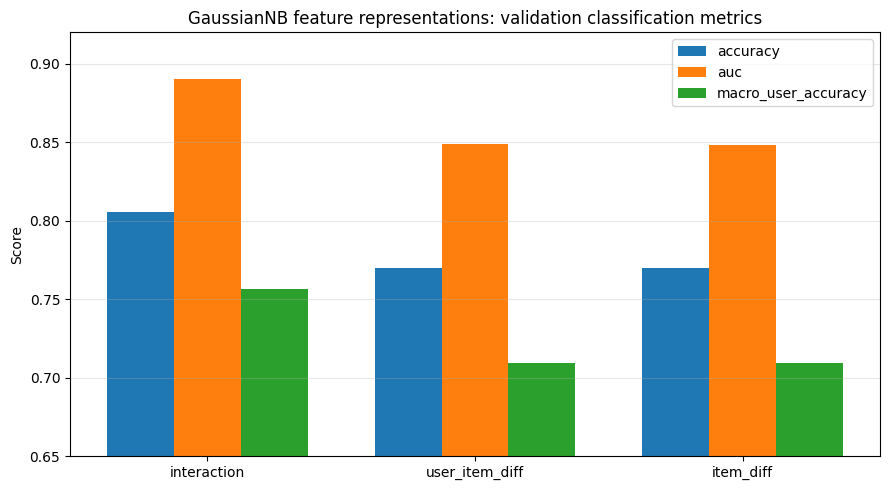

In [37]:
metrics_to_plot = [
    "accuracy",
    "auc",
    "macro_user_accuracy",
]

x = np.arange(len(bayesian_plot_df["feature_group"]))
width = 0.25

plt.figure(figsize=(9, 5))

for i, metric in enumerate(metrics_to_plot):
    plt.bar(
        x + (i - 1) * width,
        bayesian_plot_df[metric],
        width,
        label=metric,
    )

plt.xticks(x, bayesian_plot_df["feature_group"])
plt.ylim(0.65, 0.92)
plt.ylabel("Score")
plt.title("GaussianNB feature representations: validation classification metrics")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

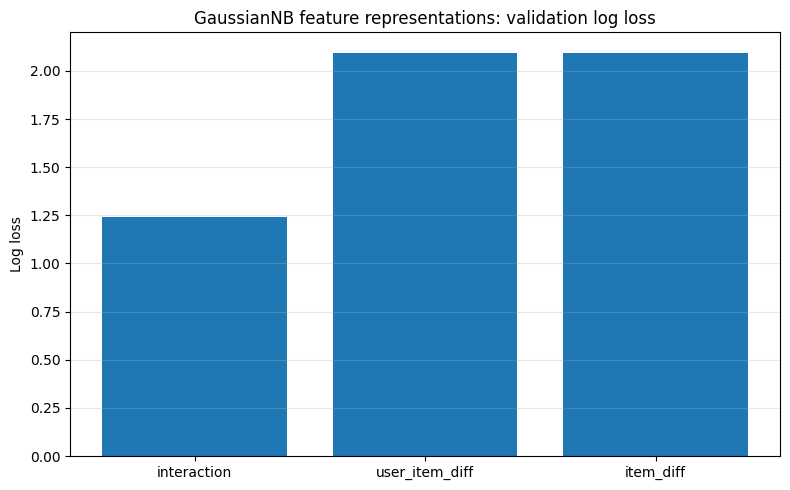

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(
    bayesian_plot_df["feature_group"],
    bayesian_plot_df["log_loss"],
)

plt.ylabel("Log loss")
plt.title("GaussianNB feature representations: validation log loss")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

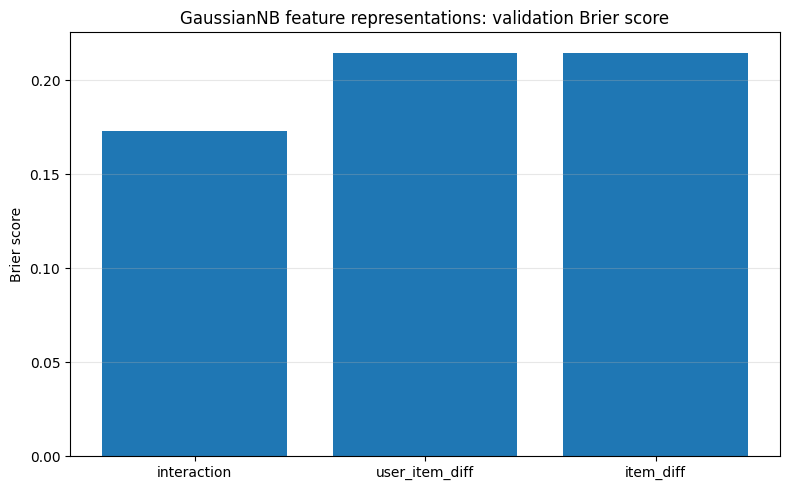

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    bayesian_plot_df["feature_group"],
    bayesian_plot_df["brier_score"],
)

plt.ylabel("Brier score")
plt.title("GaussianNB feature representations: validation Brier score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

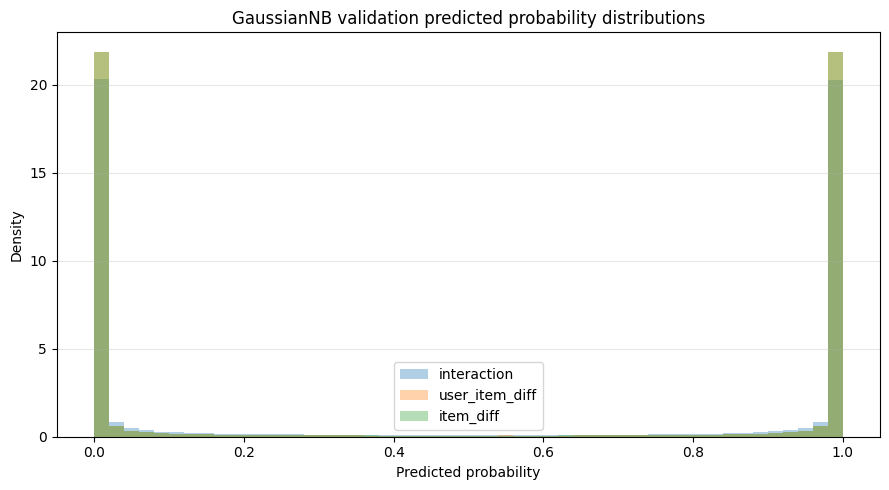

In [40]:
probability_plot_df = pd.concat(
    [
        item_diff_val_predictions[
            ["y_prob_gaussian_nb_item_diff"]
        ].rename(columns={
            "y_prob_gaussian_nb_item_diff": "y_prob"
        }).assign(feature_group="item_diff"),

        interaction_val_predictions[
            ["y_prob_gaussian_nb_interaction"]
        ].rename(columns={
            "y_prob_gaussian_nb_interaction": "y_prob"
        }).assign(feature_group="interaction"),

        user_item_diff_val_predictions[
            ["y_prob_gaussian_nb_user_item_diff"]
        ].rename(columns={
            "y_prob_gaussian_nb_user_item_diff": "y_prob"
        }).assign(feature_group="user_item_diff"),
    ],
    ignore_index=True,
)

plt.figure(figsize=(9, 5))

for feature_group in bayesian_plot_df["feature_group"]:
    subset = probability_plot_df.loc[
        probability_plot_df["feature_group"] == feature_group,
        "y_prob",
    ]

    plt.hist(
        subset,
        bins=50,
        alpha=0.35,
        density=True,
        label=feature_group,
    )

plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.title("GaussianNB validation predicted probability distributions")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.15 Bayesian feature representation decision

In [41]:
best_bayesian_row = bayesian_validation_comparison.iloc[0]

block5_decisions = pd.DataFrame([
    {
        "decision_area": "best_bayesian_feature_group",
        "selected_value": best_bayesian_row["feature_group"],
        "evidence": (
            f"On validation, {best_bayesian_row['feature_group']} achieved the best GaussianNB "
            f"accuracy={best_bayesian_row['accuracy']:.6f}, "
            f"AUC={best_bayesian_row['auc']:.6f}, "
            f"Brier score={best_bayesian_row['brier_score']:.6f}."
        ),
    },
    {
        "decision_area": "bayesian_feature_interpretation",
        "selected_value": "user-item interaction matters most",
        "evidence": (
            "The interaction representation outperformed both item_diff and user_item_diff. "
            "This shows that the useful Bayesian signal comes from p_u * (q_first - q_second), "
            "not from item vectors alone or from simply adding the user vector."
        ),
    },
    {
        "decision_area": "bayesian_probability_quality",
        "selected_value": "classification is strong, probabilities are overconfident",
        "evidence": (
            "The probability distribution plot shows many predictions near 0 or 1. "
            "This explains why GaussianNB interaction has good accuracy/AUC but relatively poor log loss and Brier score."
        ),
    },
])

display(block5_decisions)

block5_decisions.to_parquet(
    step4_dir / "block5_decisions.parquet",
    index=False,
)

,decision_area,selected_value,evidence
0,best_bayesian_feature_group,interaction,"On validation, interaction achieved the best G..."
1,bayesian_feature_interpretation,user-item interaction matters most,The interaction representation outperformed bo...
2,bayesian_probability_quality,"classification is strong, probabilities are ov...",The probability distribution plot shows many p...


# 6 Best Bayesian Model Test Evaluation
### 6.1 Confirm selected Bayesian model

In [42]:
best_bayesian_feature_group = "interaction"
best_bayesian_model_name = "GaussianNB"
best_bayesian_model = interaction_nb_model

bayesian_selected_model_summary = pd.DataFrame([
    {
        "model": best_bayesian_model_name,
        "selected_feature_group": best_bayesian_feature_group,
        "selection_split": "validation",
        "selection_reason": (
            "interaction achieved the best validation accuracy, AUC, "
            "Brier score, and macro-user accuracy among GaussianNB feature representations"
        ),
    }
])

display(bayesian_selected_model_summary)

bayesian_selected_model_summary.to_parquet(
    step4_dir / "block6_selected_bayesian_model_summary.parquet",
    index=False,
)

,model,selected_feature_group,selection_split,selection_reason
0,GaussianNB,interaction,validation,interaction achieved the best validation accur...


### 6.2 Build test features for GaussianNB interaction

In [43]:
test_arrays_full = make_directional_arrays_full(
    test_pairs_idx,
    mode="symmetric",
    random_seed=random_seed,
)

X_test_interaction, y_test_interaction = build_embedding_features(
    test_arrays_full,
    best_bayesian_feature_group,
    user_embeddings,
    item_embeddings,
    item_bias,
)

test_feature_summary = pd.DataFrame([
    {
        "model": best_bayesian_model_name,
        "feature_group": best_bayesian_feature_group,
        "split": "test",
        "mode": "symmetric",
        "rows": X_test_interaction.shape[0],
        "feature_dim": X_test_interaction.shape[1],
        "dtype": str(X_test_interaction.dtype),
        "memory_gb": X_test_interaction.nbytes / (1024 ** 3),
        "positive_share": float(y_test_interaction.mean()),
        "all_finite": bool(np.isfinite(X_test_interaction).all()),
    }
])

display(test_feature_summary.round(6))

assert test_feature_summary["all_finite"].all()
assert test_feature_summary["positive_share"].iloc[0] == 0.5

,model,feature_group,split,mode,rows,feature_dim,dtype,memory_gb,positive_share,all_finite
0,GaussianNB,interaction,test,symmetric,1015100,65,float32,0.2458,0.5,True


### 6.3 GaussianNB interaction - test evaluation

In [44]:
test_prob_interaction = best_bayesian_model.predict_proba(X_test_interaction)[:, 1]
test_pred_interaction = (test_prob_interaction >= 0.5).astype(np.int8)

bayesian_test_eval = pd.DataFrame([
    {
        "model": best_bayesian_model_name,
        "feature_group": best_bayesian_feature_group,
        "split": "test",
        "mode": "symmetric",
        "rows": len(y_test_interaction),
        "positive_share": float(y_test_interaction.mean()),
        "accuracy": accuracy_score(y_test_interaction, test_pred_interaction),
        "balanced_accuracy": balanced_accuracy_score(y_test_interaction, test_pred_interaction),
        "auc": roc_auc_score(y_test_interaction, test_prob_interaction),
        "log_loss": log_loss(y_test_interaction, test_prob_interaction, labels=[0, 1]),
        "brier_score": brier_score_loss(y_test_interaction, test_prob_interaction),
        "mean_predicted_probability": float(test_prob_interaction.mean()),
    }
])

display(bayesian_test_eval.round(6))

,model,feature_group,split,mode,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,GaussianNB,interaction,test,symmetric,1015100,0.5,0.816321,0.816321,0.897814,1.232623,0.16439,0.499621


### 6.4 GaussianNB interaction - macro-by-user test accuracy

In [45]:
test_user_eval_interaction = pd.DataFrame({
    "user_id": test_arrays_full["user_id"],
    "correct": y_test_interaction == test_pred_interaction,
})

test_user_acc_interaction = (
    test_user_eval_interaction
    .groupby("user_id")["correct"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={
        "count": "directional_examples",
        "mean": "user_accuracy",
    })
)

bayesian_test_macro = pd.DataFrame([
    {
        "model": best_bayesian_model_name,
        "feature_group": best_bayesian_feature_group,
        "split": "test",
        "users": len(test_user_acc_interaction),
        "macro_user_accuracy": float(test_user_acc_interaction["user_accuracy"].mean()),
        "median_user_accuracy": float(test_user_acc_interaction["user_accuracy"].median()),
        "p10_user_accuracy": float(test_user_acc_interaction["user_accuracy"].quantile(0.10)),
        "p25_user_accuracy": float(test_user_acc_interaction["user_accuracy"].quantile(0.25)),
        "p75_user_accuracy": float(test_user_acc_interaction["user_accuracy"].quantile(0.75)),
        "p90_user_accuracy": float(test_user_acc_interaction["user_accuracy"].quantile(0.90)),
    }
])

display(bayesian_test_macro.round(6))

,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,GaussianNB,interaction,test,4164,0.773203,0.823529,0.5,0.666667,0.9375,1.0


### 6.5 Save GaussianNB interaction test outputs

In [46]:
bayesian_test_predictions = pd.DataFrame({
    "user_id": test_arrays_full["user_id"],
    "y_true": y_test_interaction,
    "y_prob_gaussian_nb_interaction": test_prob_interaction,
    "y_pred_gaussian_nb_interaction": test_pred_interaction,
})

test_feature_summary.to_parquet(
    step4_dir / "block6_bayesian_test_feature_summary.parquet",
    index=False,
)

bayesian_test_eval.to_parquet(
    step4_dir / "block6_bayesian_test_eval.parquet",
    index=False,
)

bayesian_test_macro.to_parquet(
    step4_dir / "block6_bayesian_test_macro.parquet",
    index=False,
)

bayesian_test_predictions.to_parquet(
    step4_dir / "block6_bayesian_test_predictions.parquet",
    index=False,
)

print("Saved best Bayesian test outputs.")

Saved best Bayesian test outputs.


# 7 kNN Pairwise Predictor

### 7.1 Build user-neighborhood kNN index

In [ ]:
knn_metric = "cosine"
knn_k_candidates = [5, 10, 20, 50]
knn_max_k = max(knn_k_candidates)
knn_weight_epsilon = 1e-6

def build_user_knn_table(
    user_embeddings,
    max_k,
    metric="cosine",
    weight_epsilon=1e-6,
):
    """
    Build nearest-user table in the BPR user embedding space.

    The target user itself is excluded from its neighbor list.
    """
    n_users = user_embeddings.shape[0]

    knn_index = NearestNeighbors(
        n_neighbors=max_k + 1,
        metric=metric,
        algorithm="auto",
    )

    knn_index.fit(user_embeddings)

    distances_raw, indices_raw = knn_index.kneighbors(user_embeddings)

    neighbor_indices = np.empty((n_users, max_k), dtype=np.int32)
    neighbor_distances = np.empty((n_users, max_k), dtype=np.float32)

    for user_idx in range(n_users):
        keep_mask = indices_raw[user_idx] != user_idx

        neighbor_indices[user_idx] = indices_raw[user_idx][keep_mask][:max_k]
        neighbor_distances[user_idx] = distances_raw[user_idx][keep_mask][:max_k]

    neighbor_weights = 1.0 / (neighbor_distances + weight_epsilon)
    neighbor_weights = neighbor_weights.astype(np.float32)

    return knn_index, neighbor_indices, neighbor_distances, neighbor_weights


user_knn_index, user_neighbor_indices, user_neighbor_distances, user_neighbor_weights = build_user_knn_table(
    user_embeddings=user_embeddings,
    max_k=knn_max_k,
    metric=knn_metric,
    weight_epsilon=knn_weight_epsilon,
)

User kNN table built.


### 7.2 kNN neighbor table sanity check

In [49]:
knn_neighbor_summary = pd.DataFrame([
    {
        "metric": knn_metric,
        "max_k": knn_max_k,
        "users": user_embeddings.shape[0],
        "neighbor_indices_shape": str(user_neighbor_indices.shape),
        "neighbor_distances_shape": str(user_neighbor_distances.shape),
        "self_neighbor_count": int(
            (
                user_neighbor_indices
                == np.arange(user_embeddings.shape[0]).reshape(-1, 1)
            ).sum()
        ),
        "min_distance": float(user_neighbor_distances.min()),
        "median_distance": float(np.median(user_neighbor_distances)),
        "max_distance": float(user_neighbor_distances.max()),
        "min_weight": float(user_neighbor_weights.min()),
        "median_weight": float(np.median(user_neighbor_weights)),
        "max_weight": float(user_neighbor_weights.max()),
    }
])

display(knn_neighbor_summary.round(6))

assert knn_neighbor_summary["self_neighbor_count"].iloc[0] == 0

knn_neighbor_summary.to_parquet(
    step4_dir / "block7_2_knn_neighbor_summary.parquet",
    index=False,
)

,metric,max_k,users,neighbor_indices_shape,neighbor_distances_shape,self_neighbor_count,min_distance,median_distance,max_distance,min_weight,median_weight,max_weight
0,cosine,50,4722,"(4722, 50)","(4722, 50)",0,0.027139,0.302785,0.86973,1.149781,3.302661,36.84557


### 7.3 User-kNN distance-weighted voting evaluator

In [50]:
def evaluate_user_knn_vote(
    directional_arrays,
    split_name,
    k_values,
    user_embeddings,
    item_embeddings,
    item_bias,
    neighbor_indices,
    neighbor_weights,
    chunk_size=10_000,
):
    """
    Evaluate user-neighborhood kNN with distance-weighted binary votes.

    For each directional example:
        target user u, first item i, second item j

    Each nearest neighbor v votes using:
        score_v = p_v dot (q_i - q_j) + b_i - b_j

    vote_v = 1 if score_v >= 0 else 0

    Final probability:
        weighted share of positive neighbor votes
    """
    max_k = max(k_values)

    y_true_parts = []
    user_id_parts = []
    prob_parts_by_k = {
        k: []
        for k in k_values
    }

    n_rows = len(directional_arrays["label"])

    for start in range(0, n_rows, chunk_size):
        end = min(start + chunk_size, n_rows)

        user_idx_chunk = directional_arrays["user_idx"][start:end]
        first_idx_chunk = directional_arrays["first_item_idx"][start:end]
        second_idx_chunk = directional_arrays["second_item_idx"][start:end]

        y_chunk = directional_arrays["label"][start:end]
        user_id_chunk = directional_arrays["user_id"][start:end]

        q_diff_chunk = (
            item_embeddings[first_idx_chunk]
            - item_embeddings[second_idx_chunk]
        )

        bias_diff_chunk = (
            item_bias[first_idx_chunk]
            - item_bias[second_idx_chunk]
        )

        neighbor_idx_chunk = neighbor_indices[user_idx_chunk, :max_k]
        neighbor_weight_chunk = neighbor_weights[user_idx_chunk, :max_k]

        neighbor_embedding_chunk = user_embeddings[neighbor_idx_chunk]

        neighbor_scores = (
            np.einsum(
                "nkd,nd->nk",
                neighbor_embedding_chunk,
                q_diff_chunk,
            )
            + bias_diff_chunk.reshape(-1, 1)
        )

        neighbor_votes = (neighbor_scores >= 0).astype(np.float32)

        weighted_positive_cumsum = np.cumsum(
            neighbor_votes * neighbor_weight_chunk,
            axis=1,
        )

        weight_cumsum = np.cumsum(
            neighbor_weight_chunk,
            axis=1,
        )

        for k in k_values:
            prob_k = (
                weighted_positive_cumsum[:, k - 1]
                / weight_cumsum[:, k - 1]
            )

            prob_parts_by_k[k].append(prob_k.astype(np.float32))

        y_true_parts.append(y_chunk.astype(np.int8))
        user_id_parts.append(user_id_chunk)

        del neighbor_embedding_chunk
        del neighbor_scores
        del neighbor_votes
        del weighted_positive_cumsum
        del weight_cumsum

    y_true = np.concatenate(y_true_parts)
    user_id = np.concatenate(user_id_parts)

    eval_rows = []
    macro_rows = []
    prediction_parts = []

    for k in k_values:
        y_prob = np.concatenate(prob_parts_by_k[k])
        y_prob_for_log_loss = np.clip(y_prob, 1e-6, 1 - 1e-6)
        y_pred = (y_prob >= 0.5).astype(np.int8)

        eval_rows.append({
            "model": "UserKNN",
            "split": split_name,
            "k": k,
            "distance_metric": knn_metric,
            "vote_type": "distance_weighted_binary_vote",
            "rows": len(y_true),
            "positive_share": float(y_true.mean()),
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "auc": roc_auc_score(y_true, y_prob),
            "log_loss": log_loss(y_true, y_prob_for_log_loss, labels=[0, 1]),
            "brier_score": brier_score_loss(y_true, y_prob),
            "mean_predicted_probability": float(y_prob.mean()),
        })

        user_eval = pd.DataFrame({
            "user_id": user_id,
            "correct": y_true == y_pred,
        })

        user_acc = (
            user_eval
            .groupby("user_id")["correct"]
            .agg(["count", "mean"])
            .reset_index()
            .rename(columns={
                "count": "directional_examples",
                "mean": "user_accuracy",
            })
        )

        macro_rows.append({
            "model": "UserKNN",
            "split": split_name,
            "k": k,
            "users": len(user_acc),
            "macro_user_accuracy": float(user_acc["user_accuracy"].mean()),
            "median_user_accuracy": float(user_acc["user_accuracy"].median()),
            "p10_user_accuracy": float(user_acc["user_accuracy"].quantile(0.10)),
            "p25_user_accuracy": float(user_acc["user_accuracy"].quantile(0.25)),
            "p75_user_accuracy": float(user_acc["user_accuracy"].quantile(0.75)),
            "p90_user_accuracy": float(user_acc["user_accuracy"].quantile(0.90)),
        })

        prediction_parts.append(
            pd.DataFrame({
                "user_id": user_id,
                "y_true": y_true,
                "k": k,
                "y_prob_user_knn": y_prob,
                "y_pred_user_knn": y_pred,
            })
        )

    eval_df = pd.DataFrame(eval_rows)
    macro_df = pd.DataFrame(macro_rows)
    predictions_df = pd.concat(prediction_parts, ignore_index=True)

    return eval_df, macro_df, predictions_df

### 7.4 User-kNN validation sweep

In [51]:
val_arrays_knn = make_directional_arrays_full(
    val_pairs_idx,
    mode="symmetric",
    random_seed=random_seed,
)

knn_validation_eval, knn_validation_macro, knn_validation_predictions = evaluate_user_knn_vote(
    directional_arrays=val_arrays_knn,
    split_name="validation",
    k_values=knn_k_candidates,
    user_embeddings=user_embeddings,
    item_embeddings=item_embeddings,
    item_bias=item_bias,
    neighbor_indices=user_neighbor_indices,
    neighbor_weights=user_neighbor_weights,
    chunk_size=10_000,
)

knn_validation_eval = (
    knn_validation_eval
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

knn_validation_macro = (
    knn_validation_macro
    .sort_values("macro_user_accuracy", ascending=False)
    .reset_index(drop=True)
)

display(knn_validation_eval.round(6))
display(knn_validation_macro.round(6))

knn_validation_eval.to_parquet(
    step4_dir / "block7_4_knn_validation_eval.parquet",
    index=False,
)

knn_validation_macro.to_parquet(
    step4_dir / "block7_4_knn_validation_macro.parquet",
    index=False,
)

knn_validation_predictions.to_parquet(
    step4_dir / "block7_4_knn_validation_predictions.parquet",
    index=False,
)

,model,split,k,distance_metric,vote_type,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,UserKNN,validation,10,cosine,distance_weighted_binary_vote,956196,0.5,0.803720,0.803720,0.849625,1.712549,0.168615,0.5
1,UserKNN,validation,20,cosine,distance_weighted_binary_vote,956196,0.5,0.803394,0.803394,0.857112,1.538482,0.166728,0.5
2,UserKNN,validation,5,cosine,distance_weighted_binary_vote,956196,0.5,0.803346,0.803346,0.838996,1.944210,0.172790,0.5
3,UserKNN,validation,50,cosine,distance_weighted_binary_vote,956196,0.5,0.802735,0.802735,0.864969,1.342832,0.165226,0.5


,model,split,k,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,UserKNN,validation,10,4158,0.756012,0.8,0.479750,0.649180,0.928571,1.0
1,UserKNN,validation,50,4158,0.755542,0.8,0.488813,0.650000,0.927300,1.0
2,UserKNN,validation,20,4158,0.755439,0.8,0.483871,0.647059,0.928571,1.0
3,UserKNN,validation,5,4158,0.754379,0.8,0.478261,0.648037,0.926249,1.0


### 7.5 Select best user-kNN k

In [52]:
best_knn_row = knn_validation_eval.iloc[0]
best_knn_k = int(best_knn_row["k"])

knn_selected_model_summary = pd.DataFrame([
    {
        "model": "UserKNN",
        "selected_k": best_knn_k,
        "selection_split": "validation",
        "distance_metric": knn_metric,
        "vote_type": "distance_weighted_binary_vote",
        "selection_reason": (
            f"k={best_knn_k} achieved the best validation accuracy "
            f"among candidates {knn_k_candidates}."
        ),
    }
])

display(knn_selected_model_summary)

knn_selected_model_summary.to_parquet(
    step4_dir / "block7_5_selected_knn_model_summary.parquet",
    index=False,
)

,model,selected_k,selection_split,distance_metric,vote_type,selection_reason
0,UserKNN,10,validation,cosine,distance_weighted_binary_vote,k=10 achieved the best validation accuracy amo...


### 7.6 User-kNN selected model - test evaluation

In [ ]:
test_arrays_knn = make_directional_arrays_full(
    test_pairs_idx,
    mode="symmetric",
    random_seed=random_seed,
)

knn_test_eval, knn_test_macro, knn_test_predictions = evaluate_user_knn_vote(
    directional_arrays=test_arrays_knn,
    split_name="test",
    k_values=[best_knn_k],
    user_embeddings=user_embeddings,
    item_embeddings=item_embeddings,
    item_bias=item_bias,
    neighbor_indices=user_neighbor_indices,
    neighbor_weights=user_neighbor_weights,
    chunk_size=10_000,
)

display(knn_test_eval.round(6))
display(knn_test_macro.round(6))

,model,split,k,distance_metric,vote_type,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,UserKNN,test,10,cosine,distance_weighted_binary_vote,1015100,0.5,0.814647,0.814647,0.856734,1.679767,0.161097,0.5


,model,split,k,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,UserKNN,test,10,4164,0.772449,0.818714,0.5,0.666667,0.9375,1.0


### 7.7 Save selected UserKNN test outputs

In [54]:
knn_test_eval.to_parquet(
    step4_dir / "block7_6_knn_test_eval.parquet",
    index=False,
)

knn_test_macro.to_parquet(
    step4_dir / "block7_6_knn_test_macro.parquet",
    index=False,
)

knn_test_predictions.to_parquet(
    step4_dir / "block7_6_knn_test_predictions.parquet",
    index=False,
)

print("Saved selected UserKNN test outputs.")

Saved selected UserKNN test outputs.


# Model Comparison
### 8.1 MF baseline full validation/test directional evaluation

In [56]:
from scipy.special import expit

def evaluate_probability_predictions(
    y_true,
    y_prob,
    user_id,
    model_name,
    split_name,
    feature_group=None,
    extra_info=None,
):
    y_prob_safe = np.clip(y_prob, 1e-6, 1 - 1e-6)
    y_pred = (y_prob >= 0.5).astype(np.int8)

    eval_row = {
        "model": model_name,
        "feature_group": feature_group,
        "split": split_name,
        "rows": len(y_true),
        "positive_share": float(y_true.mean()),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob_safe, labels=[0, 1]),
        "brier_score": brier_score_loss(y_true, y_prob),
        "mean_predicted_probability": float(y_prob.mean()),
    }

    if extra_info is not None:
        eval_row.update(extra_info)

    user_eval = pd.DataFrame({
        "user_id": user_id,
        "correct": y_true == y_pred,
    })

    user_acc = (
        user_eval
        .groupby("user_id")["correct"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={
            "count": "directional_examples",
            "mean": "user_accuracy",
        })
    )

    macro_row = {
        "model": model_name,
        "feature_group": feature_group,
        "split": split_name,
        "users": len(user_acc),
        "macro_user_accuracy": float(user_acc["user_accuracy"].mean()),
        "median_user_accuracy": float(user_acc["user_accuracy"].median()),
        "p10_user_accuracy": float(user_acc["user_accuracy"].quantile(0.10)),
        "p25_user_accuracy": float(user_acc["user_accuracy"].quantile(0.25)),
        "p75_user_accuracy": float(user_acc["user_accuracy"].quantile(0.75)),
        "p90_user_accuracy": float(user_acc["user_accuracy"].quantile(0.90)),
    }

    if extra_info is not None:
        macro_row.update(extra_info)

    predictions = pd.DataFrame({
        "user_id": user_id,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    })

    return pd.DataFrame([eval_row]), pd.DataFrame([macro_row]), predictions


val_arrays_mf = make_directional_arrays_full(
    val_pairs_idx,
    mode="symmetric",
    random_seed=random_seed,
)

test_arrays_mf = make_directional_arrays_full(
    test_pairs_idx,
    mode="symmetric",
    random_seed=random_seed,
)

val_mf_score = compute_mf_score_from_directional_arrays(
    val_arrays_mf,
    user_embeddings,
    item_embeddings,
    item_bias,
)

test_mf_score = compute_mf_score_from_directional_arrays(
    test_arrays_mf,
    user_embeddings,
    item_embeddings,
    item_bias,
)

val_mf_prob = expit(val_mf_score)
test_mf_prob = expit(test_mf_score)

mf_val_eval, mf_val_macro, mf_val_predictions = evaluate_probability_predictions(
    y_true=val_arrays_mf["label"],
    y_prob=val_mf_prob,
    user_id=val_arrays_mf["user_id"],
    model_name="MF_BPR",
    split_name="validation",
    feature_group="p_u_dot_q_diff_plus_bias",
)

mf_test_eval, mf_test_macro, mf_test_predictions = evaluate_probability_predictions(
    y_true=test_arrays_mf["label"],
    y_prob=test_mf_prob,
    user_id=test_arrays_mf["user_id"],
    model_name="MF_BPR",
    split_name="test",
    feature_group="p_u_dot_q_diff_plus_bias",
)

display(mf_val_eval.round(6))
display(mf_test_eval.round(6))
display(mf_val_macro.round(6))
display(mf_test_macro.round(6))

,model,feature_group,split,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,MF_BPR,p_u_dot_q_diff_plus_bias,validation,956196,0.5,0.809004,0.809004,0.896833,0.402563,0.130652,0.5


,model,feature_group,split,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability
0,MF_BPR,p_u_dot_q_diff_plus_bias,test,1015100,0.5,0.818034,0.818034,0.903393,0.393546,0.125943,0.5


,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,MF_BPR,p_u_dot_q_diff_plus_bias,validation,4158,0.760839,0.801585,0.5,0.660836,0.928571,1.0


,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy
0,MF_BPR,p_u_dot_q_diff_plus_bias,test,4164,0.774218,0.823529,0.5,0.666667,0.938838,1.0


### 8.2 Final comparison: MF vs best Bayesian vs selected UserKNN

In [57]:
bayesian_val_eval_final = interaction_val_eval.copy()
bayesian_val_macro_final = interaction_val_macro.copy()

bayesian_test_eval_final = bayesian_test_eval.copy()
bayesian_test_macro_final = bayesian_test_macro.copy()

knn_val_eval_final = (
    knn_validation_eval
    .loc[knn_validation_eval["k"] == best_knn_k]
    .copy()
)

knn_val_macro_final = (
    knn_validation_macro
    .loc[knn_validation_macro["k"] == best_knn_k]
    .copy()
)

knn_test_eval_final = knn_test_eval.copy()
knn_test_macro_final = knn_test_macro.copy()

final_validation_comparison = pd.concat(
    [
        mf_val_eval,
        bayesian_val_eval_final,
        knn_val_eval_final,
    ],
    ignore_index=True,
)

final_test_comparison = pd.concat(
    [
        mf_test_eval,
        bayesian_test_eval_final,
        knn_test_eval_final,
    ],
    ignore_index=True,
)

final_validation_macro_comparison = pd.concat(
    [
        mf_val_macro,
        bayesian_val_macro_final,
        knn_val_macro_final,
    ],
    ignore_index=True,
)

final_test_macro_comparison = pd.concat(
    [
        mf_test_macro,
        bayesian_test_macro_final,
        knn_test_macro_final,
    ],
    ignore_index=True,
)

display(final_validation_comparison.round(6))
display(final_test_comparison.round(6))

display(final_validation_macro_comparison.round(6))
display(final_test_macro_comparison.round(6))

final_validation_comparison.to_parquet(
    step4_dir / "block8_final_validation_comparison.parquet",
    index=False,
)

final_test_comparison.to_parquet(
    step4_dir / "block8_final_test_comparison.parquet",
    index=False,
)

final_validation_macro_comparison.to_parquet(
    step4_dir / "block8_final_validation_macro_comparison.parquet",
    index=False,
)

final_test_macro_comparison.to_parquet(
    step4_dir / "block8_final_test_macro_comparison.parquet",
    index=False,
)

,model,feature_group,split,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability,mode,k,distance_metric,vote_type
0,MF_BPR,p_u_dot_q_diff_plus_bias,validation,956196,0.5,0.809004,0.809004,0.896833,0.402563,0.130652,0.500000,NaN,NaN,NaN,NaN
1,GaussianNB,interaction,validation,956196,0.5,0.805405,0.805405,0.890407,1.239084,0.172889,0.499593,symmetric,NaN,NaN,NaN
2,UserKNN,NaN,validation,956196,0.5,0.803720,0.803720,0.849625,1.712549,0.168615,0.500000,NaN,10.0,cosine,distance_weighted_binary_vote


,model,feature_group,split,rows,positive_share,accuracy,balanced_accuracy,auc,log_loss,brier_score,mean_predicted_probability,mode,k,distance_metric,vote_type
0,MF_BPR,p_u_dot_q_diff_plus_bias,test,1015100,0.5,0.818034,0.818034,0.903393,0.393546,0.125943,0.500000,NaN,NaN,NaN,NaN
1,GaussianNB,interaction,test,1015100,0.5,0.816321,0.816321,0.897814,1.232623,0.164390,0.499621,symmetric,NaN,NaN,NaN
2,UserKNN,NaN,test,1015100,0.5,0.814647,0.814647,0.856734,1.679767,0.161097,0.500000,NaN,10.0,cosine,distance_weighted_binary_vote


,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,k
0,MF_BPR,p_u_dot_q_diff_plus_bias,validation,4158,0.760839,0.801585,0.500000,0.660836,0.928571,1.0,NaN
1,GaussianNB,interaction,validation,4158,0.756299,0.800000,0.471732,0.652174,0.928745,1.0,NaN
2,UserKNN,NaN,validation,4158,0.756012,0.800000,0.479750,0.649180,0.928571,1.0,10.0


,model,feature_group,split,users,macro_user_accuracy,median_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,k
0,MF_BPR,p_u_dot_q_diff_plus_bias,test,4164,0.774218,0.823529,0.5,0.666667,0.938838,1.0,NaN
1,GaussianNB,interaction,test,4164,0.773203,0.823529,0.5,0.666667,0.937500,1.0,NaN
2,UserKNN,NaN,test,4164,0.772449,0.818714,0.5,0.666667,0.937500,1.0,10.0


### 8.3 Final test comparison plots

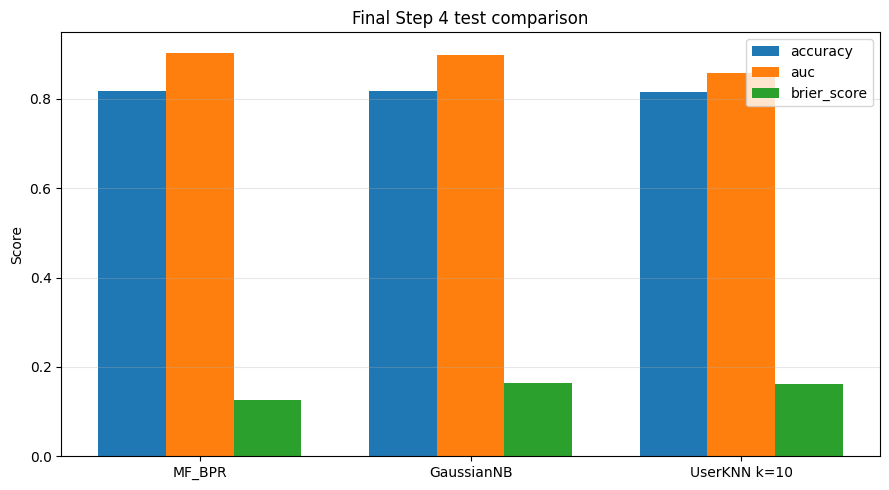

In [58]:
plot_test_df = final_test_comparison.copy()

plot_test_df["model_label"] = plot_test_df.apply(
    lambda row: (
        f"{row['model']} k={int(row['k'])}"
        if "k" in row.index and not pd.isna(row.get("k", np.nan))
        else row["model"]
    ),
    axis=1,
)

classification_metrics = [
    "accuracy",
    "auc",
    "brier_score",
]

x = np.arange(len(plot_test_df["model_label"]))
width = 0.25

plt.figure(figsize=(9, 5))

for i, metric in enumerate(classification_metrics):
    plt.bar(
        x + (i - 1) * width,
        plot_test_df[metric],
        width,
        label=metric,
    )

plt.xticks(x, plot_test_df["model_label"])
plt.ylabel("Score")
plt.title("Final Step 4 test comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 8.3.1 Final test log loss plot

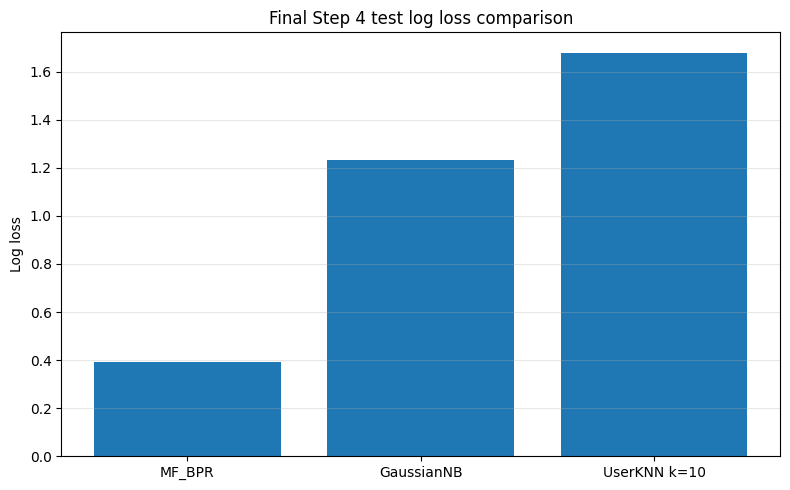

In [59]:
plt.figure(figsize=(8, 5))

plt.bar(
    plot_test_df["model_label"],
    plot_test_df["log_loss"],
)

plt.ylabel("Log loss")
plt.title("Final Step 4 test log loss comparison")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 8.4 Where does kNN beat MF?

In [60]:
### 8.4.1 Build shared MF vs UserKNN test prediction table

mf_vs_knn_test = pd.DataFrame({
    "user_id": mf_test_predictions["user_id"],
    "y_true": mf_test_predictions["y_true"],
    "mf_prob": mf_test_predictions["y_prob"],
    "mf_pred": mf_test_predictions["y_pred"],
    "knn_prob": knn_test_predictions["y_prob_user_knn"],
    "knn_pred": knn_test_predictions["y_pred_user_knn"],
})

assert (mf_vs_knn_test["user_id"].to_numpy() == knn_test_predictions["user_id"].to_numpy()).all()
assert (mf_vs_knn_test["y_true"].to_numpy() == knn_test_predictions["y_true"].to_numpy()).all()

mf_vs_knn_test["mf_correct"] = (
    mf_vs_knn_test["y_true"] == mf_vs_knn_test["mf_pred"]
)

mf_vs_knn_test["knn_correct"] = (
    mf_vs_knn_test["y_true"] == mf_vs_knn_test["knn_pred"]
)

mf_vs_knn_test["knn_minus_mf_correct"] = (
    mf_vs_knn_test["knn_correct"].astype(int)
    - mf_vs_knn_test["mf_correct"].astype(int)
)

mf_vs_knn_test["knn_confidence"] = (
    mf_vs_knn_test["knn_prob"] - 0.5
).abs()

display(mf_vs_knn_test.head())

,user_id,y_true,mf_prob,mf_pred,knn_prob,knn_pred,mf_correct,knn_correct,knn_minus_mf_correct,knn_confidence
0,2,1,0.817171,1,1.000000,1,True,True,0,0.500000
1,2,1,0.324376,0,0.200651,0,False,False,0,0.299349
2,2,1,0.646831,1,1.000000,1,True,True,0,0.500000
3,2,1,0.122794,0,0.000000,0,False,False,0,0.500000
4,2,1,0.664228,1,1.000000,1,True,True,0,0.500000


In [ ]:
### 8.4.2 Add train activity buckets

user_train_activity = (
    train_pairs_idx
    .groupby("user_id")
    .size()
    .reset_index(name="train_pair_count")
)

mf_vs_knn_test = mf_vs_knn_test.merge(
    user_train_activity,
    on="user_id",
    how="left",
)

assert mf_vs_knn_test["train_pair_count"].notna().all()

mf_vs_knn_test["train_activity_bucket"] = pd.qcut(
    mf_vs_knn_test["train_pair_count"],
    q=4,
    labels=[
        "Q1 lowest train activity",
        "Q2",
        "Q3",
        "Q4 highest train activity",
    ],
    duplicates="drop",
)

activity_bucket_comparison = (
    mf_vs_knn_test
    .groupby("train_activity_bucket", observed=True)
    .agg(
        rows=("y_true", "size"),
        users=("user_id", "nunique"),
        mean_train_pair_count=("train_pair_count", "mean"),
        mf_accuracy=("mf_correct", "mean"),
        knn_accuracy=("knn_correct", "mean"),
        knn_minus_mf_accuracy=("knn_minus_mf_correct", "mean"),
        mean_knn_confidence=("knn_confidence", "mean"),
    )
    .reset_index()
)

display(activity_bucket_comparison.round(6))

activity_bucket_comparison.to_parquet(
    step4_dir / "block8_4_activity_bucket_mf_vs_knn.parquet",
    index=False,
)

ValueError: Bin labels must be one fewer than the number of bin edges